In [1]:
from transformers import AutoModelForSeq2SeqLM, AutoTokenizer, TrainingArguments, Trainer
#from transformers import BitsAndBytesConfig
import spacy
import torch
from yahooquery import search
from spacy.language import Language
from spacy import displacy
import time
import glob
import re
import math
import statistics
import os
import json
import calendar
import holidays
from pathlib import Path
from datetime import date
from datetime import datetime
import pandas as pd
import numpy as np
import collections
import hashlib
from dateutil.parser import parse
import shutil
import ast
from io import StringIO
import requests
import glob
import os

In [2]:
alias_file = "../../Summary/OTHER/aliases.json"
if os.path.exists(alias_file):
    with open(alias_file, 'r') as f:
        alias = json.load(f)
print(alias)

{'MAUS': 'MONTHLY ACTIVE USERS', 'ARR': 'ANNUAL RECURRING REVENUE', 'ARPU': 'ACTIVE REVENUE PER USER', 'ANNUAL RECURRING REVENUE ARR': 'ANNUAL RECURRING REVENUE', 'ANNUALIZED RECURRING REVENUE': 'ANNUAL RECURRING REVENUE', 'ANNUALIZED RECURRING REVENUE ARR': 'ANNUAL RECURRING REVENUE', 'NET NEW ARR': 'NET NEW ANNUAL RECURRING REVENUE', 'NET DOLLAR EXPANSION CUSTOMERS WITH MORE THAN 10 EMPLOYEES': 'NET DOLLAR EXPANSION', 'CUSTOMERS CONTRIBUTING MORE THAN $100,000 REVENUE': 'LARGE PAID CUSTOMERS', 'CUSTOMERS CONTRIBUTING MORE THAN $100,000 TTM REVENUE': 'LARGE PAID CUSTOMERS', 'CUSTOMERS WITH MORE THAN $100000 OF ARR': 'LARGE PAID CUSTOMERS', 'CUSTOMERS CONTRIBUTING MORE THAN $100,000 IN REVENUE': 'LARGE PAID CUSTOMERS', 'CUSTOMERS WITH MORE THAN 10 EMPLOYEES': 'TOTAL NUMBER OF PAID CUSTOMERS', 'BUSINESSES': 'TOTAL NUMBER OF PAID CUSTOMERS', 'NET NEW SUBSCRIPTION CUSTOMERS': 'NEW PAID CUSTOMERS', 'SUBSCRIPTION CUSTOMERS': 'TOTAL NUMBER OF PAID CUSTOMERS', 'CUSTOMER COUNT': 'TOTAL NUMBER 

In [3]:
reverse_alias = dict()
for key in alias.keys():
    val = alias[key]
    if(val not in reverse_alias):
        reverse_alias[val] = list()
    reverse_alias[val].append(key)
print(reverse_alias)

{'MONTHLY ACTIVE USERS': ['MAUS', 'MAUS-GLOBAL', 'GLOBAL MONTHLY ACTIVE USERS MAUS', 'GLOBAL MONTHLY ACTIVE USERS'], 'ANNUAL RECURRING REVENUE': ['ARR', 'ANNUAL RECURRING REVENUE ARR', 'ANNUALIZED RECURRING REVENUE', 'ANNUALIZED RECURRING REVENUE ARR', 'ANNUAL RUN-RATE REVENUE ARR', 'ANNUALIZED EXIT MONTHLY RECURRING SUBSCRIPTIONS ARR', 'RINGCENTRAL TOTAL ARR', 'ENDING ARR'], 'ACTIVE REVENUE PER USER': ['ARPU', 'AVERAGE REVENUE PER CUSTOMER ARPU', 'AVERAGE REVENUE PER CUSTOMER', 'ARPU-GLOBAL'], 'NET NEW ANNUAL RECURRING REVENUE': ['NET NEW ARR'], 'NET DOLLAR EXPANSION': ['NET DOLLAR EXPANSION CUSTOMERS WITH MORE THAN 10 EMPLOYEES', 'NET DOLLAR EXPANSION CUSTOMERS WITH GREATER THAN 10 EMPLOYEES', 'REVENUE RETENTION', 'NET DOLLAR EXPANSION TOTAL NUMBER OF CUSTOMERS', 'RETENTION RATE', 'SUBSCRIPTION REVENUE RETENTION RATE', 'NET REVENUE RETENTION', 'NET DOLLAR - BASED RETENTION RATE', 'SUBSCRIPTION REVENUE NET DOLLAR EXPANSION', 'NET DOLLAR RETENTION NDR', 'NET DOLLAR RETENTION', 'NET RET

In [4]:
org_to_sym = dict()

In [6]:
maxEntCount = 12
naStr = "Not enough information is available."
special_keys = ["OPERATIONAL METRICS"]
ansTemplateStr = dict()
ansTemplateStr["1"] = "*METRIC of *ORG in quarter *QTR year *YEAR was *RESULT. " 
ansTemplateStr["2"] = "*ORG reported *COUNT *METRIC in quarter *QTR year *YEAR, these were:\n*RESULT"
ansTemplateStr["3"] = "*RESULT. *ORG *CHG *METRIC consensus guidance in *QTR *YEAR. *METRIC is *NUMBER, *CHG by *MARGIN in *QTR *YEAR."
ansTemplateStr["4"] = "*RESULT. *ORG *CHG *METRIC consensus guidance for *GQTR *GYR. *METRIC guidance is *NUMBER, *CHG consensus guidance by *MARGIN in *GQTR *GYR."
ansTemplateStr["5"] = "*RESULT. *ORG *CHG *METRIC guidance for full fiscal year *GYR. *METRIC midpoint guidance is *NUMBER, *CHG by *MARGIN for fiscal year *GYR."
ansTemplateStr["6"] = "In *GQTR year *GYR, *ORG expects *METRIC to be around *RESULT at its midpoint. "
ansTemplateStr["7"] = "For fiscal year *GYR, *ORG expects *METRIC to be around *RESULT at its midpoint. "
ansTemplateStr["8"] = "*RESULT. In latest quarter *QTR year *YEAR, *METRIC of *ORG *CHG by *NUMBER basis point. "

In [7]:
def getOrgData(org):
    orgDataPath = "../../Summary/orgData/"+org+".txt"
    file = Path(orgDataPath)
    if file.is_file():
        #print(True)
        with open(orgDataPath) as f:
            data = json.load(f)
        #print(data)
        return data
    return None

In [9]:
def getOrgAttr(orgData, attr):
    if not orgData:
        return None
    asplit = attr.split("|")
    parent = asplit[0]
    if parent in orgData and "SOURCE" in orgData[parent]:
        src = orgData[parent]["SOURCE"]
        if src == "YH" or (parent == "ORGPROFILE" and src == "AD"):
            p = orgData
            for i in range(0, len(asplit)):
                if asplit[i] not in p:
                    return None
                p = p[asplit[i]]
            #print(p)
            return(p)
    return None

In [10]:
def getPrevQtr(qstr):
    if not qstr:
        return None
    prvQtr = None
    qs = qstr.split("-")[0]
    year = qstr.split("-")[1]
    if(qs == "Q1"):
        year = (int(year) - 1)
        prvQtr = "Q4-"+str(year)
    elif(qs == "Q2"):
        prvQtr = "Q1-"+str(year)
    elif(qs == "Q3"):
        prvQtr = "Q2-"+str(year)
    elif(qs == "Q4"):
        prvQtr = "Q3-"+str(year)
    return(prvQtr)

In [11]:
def getEntAttr(entData, attr):
    if not entData:
        return None
    asplit = attr.split("|")
    
    p = entData
    for i in range(0, len(asplit)):
        if asplit[i] not in p:
            return None
        p = p[asplit[i]]
    #print(p)
    return(p)

In [12]:
def getAttr(allEntities, source, attrList):
    if source not in allEntities:
        return None
    p = allEntities[source]
    if not attrList:
        return p
    asplit = attrList.split("|")
    for i in range(0, len(asplit)):
        if asplit[i] not in p:
            return None
        p = p[asplit[i]]
        #print(p)
    return(p)
    #return None

In [13]:
def isMetricPresent(source, metric):
    if metric not in source:
        return False
    if metric in source and "CONFLICT" in source[metric] and source[metric]["CONFLICT"]:
        return False
    return True

In [14]:
def name_to_symbol(company_name):
    results = search(company_name)
    if(results and "quotes" in results):
        return results["quotes"][0]["symbol"]
    return None

In [15]:
def get_earning_details(csym):
    entPath = "../../Summary/entities/"+csym+"-ENTITIES.json"
    entFile = Path(entPath)
    entities = None
    with open(entPath, encoding="utf-8") as f:
        entity = json.load(f)
        entities = entity[csym]
    return(entities)

In [16]:
def getEntities(sym):
    entPath = "../../Summary/entities/"+sym+"-ENTITIES.json"
    entFile = Path(entPath)
    entities = None
    allEntities = None
    if entFile.is_file():
        with open(entPath, encoding="utf-8") as f:
            entity = json.load(f)
            entities = entity[sym]
            allEntities = dict()
            orgData = getOrgData(sym)
            allEntities["ORGDATA"] = orgData
            allEntities["ENTITIES"] = entities
            #allEntities["ENTITY"] = entity
    return allEntities

In [17]:
import ast
import operator

# Supported operators
OPS = {
    ast.Eq: operator.eq,
    ast.NotEq: operator.ne,
    ast.Lt: operator.lt,
    ast.LtE: operator.le,
    ast.Gt: operator.gt,
    ast.GtE: operator.ge,
    ast.And: lambda a, b: a and b,
    ast.Or: lambda a, b: a or b,
}

def normalize_keys(obj):
    if isinstance(obj, dict):
        return {k.replace("-", "_").replace(" ","_"): normalize_keys(v) for k, v in obj.items()}
    elif isinstance(obj, list):
        return [normalize_keys(i) for i in obj]
    return obj

def deep_get(data, dotted_path):
    """Retrieve nested key using dot notation safely."""
    keys = dotted_path.split(".")
    for k in keys:
        if isinstance(data, dict):
            data = data.get(k)
        elif isinstance(data, list):
            try:
                data = data[int(k)]
            except (ValueError, IndexError):
                return None
        else:
            return None
    return data

def safe_eval_expr(node, context):
    """Recursively evaluate AST expression safely using nested JSON context."""
    try:
        if isinstance(node, ast.BoolOp):  # logical and/or
            left = safe_eval_expr(node.values[0], context)
            for v in node.values[1:]:
                right = safe_eval_expr(v, context)
                left = OPS[type(node.op)](left, right)
            return left

        elif isinstance(node, ast.Compare):  # comparisons
            left = safe_eval_expr(node.left, context)
            right = safe_eval_expr(node.comparators[0], context)
            op = OPS.get(type(node.ops[0]))
            if op is None:
                raise ValueError(f"Unsupported operator: {ast.dump(node.ops[0])}")
            return op(left, right)

        elif isinstance(node, ast.Attribute):
            # Handle dotted attribute like metrics.revenue.amount
            return deep_get(context, get_full_attr_path(node))

        elif isinstance(node, ast.Name):
            # top-level variable
            return context.get(node.id, None)

        elif isinstance(node, ast.Constant):
            return node.value

        elif hasattr(ast, "Num") and isinstance(node, ast.Num):
            return node.n

        elif hasattr(ast, "Str") and isinstance(node, ast.Str):
            return node.s

        else:
            return None
            #raise ValueError(f"Unsupported expression: {ast.dump(node)}")
    except:
        return None

def get_full_attr_path(node):
    """Reconstruct dotted attribute path."""
    parts = []
    while isinstance(node, ast.Attribute):
        parts.append(node.attr)
        node = node.value
    if isinstance(node, ast.Name):
        parts.append(node.id)
    return ".".join(reversed(parts))

def apply_json_filter(data, condition_str):
    """Apply logical filter to nested JSON data."""
    try:
        expr = ast.parse(condition_str, mode="eval").body
        return safe_eval_expr(expr, data)
    except:
        return False

In [18]:
entities = getEntities("APPN")
latest_qtr = entities["ENTITIES"]["LATEST-QTR"]
allData = entities["ENTITIES"][latest_qtr]
allData = normalize_keys(allData)
filter_expr = 'ANY.TEXT_METRICTYPE=="OPMETRIC"'
for ft in allData:
    nfilter_expr = filter_expr.replace("ANY.",ft+".")
    #print(nfilter_expr)
    result = apply_json_filter(allData, nfilter_expr)
    #print(nfilter_expr, result)
    if(result == True):
        print(ft)

SUBSCRIPTION_REVENUE_CLOUD
SUBSCRIPTIONS_REVENUE
PROFESSIONAL_SERVICES_REVENUE
NET_DOLLAR_EXPANSION


In [19]:
def list_quarter_range(start_qtr, end_qtr, calendar="QUARTERLY"):
    """
    Generate list of quarters in Qx-YYYY format between given start and end (inclusive).
    Example: Q2-2023 → Q4-2024
    """
    def parse_qtr(qtr_str):
        q, y = qtr_str.split('-')
        if(q == "ALL" and calendar == "QUARTERLY"):
            q = "Q1"
        if(calendar == "QUARTERLY"):
            return int(q[1]), int(y)  # (quarter_num, year)
        else:
            return "ALL", int(y) 

    start_q, start_y = parse_qtr(start_qtr)
    end_q, end_y = parse_qtr(end_qtr)
    #print(start_q, start_y, end_q, end_y)
    
    if((start_q == end_q == 1) and "ALL-" in start_qtr and "ALL-" in end_qtr):
        end_q = 4
    elif("ALL-" not in start_qtr and "ALL-" in end_qtr):
        end_q = 4

    result = []
    y, q = start_y, start_q

    if(calendar == "QUARTERLY"):
        while (y < end_y) or (y == end_y and q <= end_q):
            result.append(f"Q{q}-{y}")
            q += 1
            if q > 4:
                q = 1
                y += 1
    else:
        while (y < end_y or (y == end_y)):
            result.append(f"{q}-{y}")
            y += 1

    return result

In [20]:
print(list_quarter_range("Q2-2023", "Q2-2025", "QUARTERLY"))

['Q2-2023', 'Q3-2023', 'Q4-2023', 'Q1-2024', 'Q2-2024', 'Q3-2024', 'Q4-2024', 'Q1-2025', 'Q2-2025']


In [21]:
key_alias = dict()
key_alias["POSFACTS"] = "POSITIVE FACTS"
key_alias["NEGFACTS"] = "NEGATIVE FACTS"
#key_alias["POSITIVE FACTS"] = "POSFACTS"
#key_alias["NEGATIVE FACTS"] = "NEGFACTS"
#key_alias["POSITIVE POINTS"] = "POSFACTS"
#key_alias["NEGATIVE POINTS"] = "NEGFACTS"
#key_alias["EPS YOY"] = "EPS-YOY"
print(key_alias)

{'POSFACTS': 'POSITIVE FACTS', 'NEGFACTS': 'NEGATIVE FACTS'}


In [22]:
key_to_fields_alias = dict()
key_to_fields_alias["POSITIVE FACTS"] = {"FIELDS": ["POSFACTS"], "SOURCE": ["ENTITY"]}
key_to_fields_alias["NEGATIVE FACTS"] = {"FIELDS": ["NEGFACTS"], "SOURCE": ["ENTITY"]}
#key_to_fields_alias["RANKING"] = {"FIELDS": ["RANK"], "SOURCE": ["ENTITY"]}
#key_to_fields_alias["RANKING TREND"] = {"FIELDS": ["RANK"], "SOURCE": ["ENTITY"]}
key_to_fields_alias["POSITIVE FACTS COUNT"] = {"FIELDS": ["POSFACTS"], "SOURCE": ["ENTITY"], "OP": ["COUNT"]}
key_to_fields_alias["NEGATIVE FACTS COUNT"] = {"FIELDS": ["NEGFACTS"], "SOURCE": ["ENTITY"], "OP": ["COUNT"]}
key_to_fields_alias["*KEY YOY GROWTH ACCELARATING?"] = {"FIELDS": ['*KEY GROWTH RATE-YOY'], "SOURCE": ["ENTITY"], "OP": ["BOOL"]}
key_to_fields_alias["BEAT *KEY EXPECTATION?"] = {"FIELDS": ['*KEY-*-RESULT', '*KEY-*'], "SOURCE": ["ENTITY"]}
key_to_fields_alias["BEAT *KEY GUIDANCE?"] = {"FIELDS": ['*KEY-*-RESULT', '*KEY-*'], "SOURCE": ["ENTITY"]}
key_to_fields_alias["RAISE *KEY GUIDANCE?"] = {"FIELDS": ['*KEY-*-RESULT', '*KEY-*'], "SOURCE": ["ENTITY"]}
key_to_fields_alias["OPERATIONAL METRICS"] = {"FIELDS": [], "SOURCE": []}
key_to_fields_alias["OPERATIONAL METRICS YOY GROWTH GUIDANCE"] = {"FIELDS": [], "SOURCE": []}
key_to_fields_alias["OPERATIONAL METRICS YOY GROWTH"] = {"FIELDS": [], "SOURCE": []}
key_to_fields_alias["OPERATIONAL METRICS QOQ GROWTH GUIDANCE"] = {"FIELDS": [], "SOURCE": []}
key_to_fields_alias["OPERATIONAL METRICS QOQ GROWTH"] = {"FIELDS": [], "SOURCE": []}
key_to_fields_alias["*KEY GROWTH"] = {"FIELDS": ['*KEY', '*KEY-QOQ', '*KEY-YOY', 'GUIDANCE', 'GUIDE-QOQ', 'GUIDE-YOY'], "SOURCE": ["ENTITY"]}
key_to_fields_alias["*KEY GROWTH QUARTERLY"] = {"FIELDS": ['*KEY', '*KEY-QOQ', '*KEY-YOY', 'GUIDANCE', 'GUIDE-QOQ', 'GUIDE-YOY'], "SOURCE": ["ENTITY"]}
key_to_fields_alias["*KEY GROWTH YEARLY"] = {"FIELDS": ['*KEY', '*KEY-YOY', 'GUIDANCE', 'GUIDE-YOY'], "SOURCE": ["ENTITY"]}
key_to_fields_alias["*KEY"] = {"FIELDS": ['*KEY-*', '*KEY-*-QOQ', '*KEY-*-YOY'], "SOURCE": ["ENTITY"]}
key_to_fields_alias["*KEY TREND"] = {"FIELDS": ['*KEY'], "SOURCE": ["ENTITY"]}
key_to_fields_alias["YOY *KEY GROWTH"] = {"FIELDS": ['*KEY-YOY'], "SOURCE": ["ENTITY"]}
key_to_fields_alias["QOQ *KEY GROWTH"] = {"FIELDS": ['*KEY-QOQ'], "SOURCE": ["ENTITY"]}
key_to_fields_alias["*KEY QOQ GROWTH"] = {"FIELDS": ['*KEY-QOQ'], "SOURCE": ["ENTITY"]}
key_to_fields_alias["*KEY YOY GROWTH"] = {"FIELDS": ['*KEY-YOY'], "SOURCE": ["ENTITY"]}
key_to_fields_alias["*KEY VS *KEY GUIDANCE CONSENSUS"] = {"FIELDS": ["*KEY", "*KEY-GUIDE-CSUS", "GUIDANCE", "GUIDE-CSUS-ORIG"], "SOURCE": ["ENTITY"]}
key_to_fields_alias["CURRENT *KEY AND GUIDANCE TREND"] = {"FIELDS": ["*KEY-GUIDE-PREV","*KEY","*KEY-GUIDE"], "SOURCE": ["ENTITY"]}
key_to_fields_alias["*KEY YOY GROWTH GUIDANCE"] = {"FIELDS": ['*KEY-YOY', "GUIDANCE", "GUIDE-YOY"], "SOURCE": ["ENTITY"]}
key_to_fields_alias["*KEY QOQ GROWTH GUIDANCE"] = {"FIELDS": ['*KEY-QOQ', "GUIDANCE", "GUIDE-QOQ"], "SOURCE": ["ENTITY"]}
key_to_fields_alias["YEARLY *KEY VS YEARLY GUIDANCE"] = {"FIELDS": ["*KEY-FULLYEAR","*KEY-FULLYEAR-YOY","*KEY-GUIDEFULL","*KEY-GUIDEFULL-YOY"], "SOURCE": ["ENTITY"]}
print(key_to_fields_alias)

{'POSITIVE FACTS': {'FIELDS': ['POSFACTS'], 'SOURCE': ['ENTITY']}, 'NEGATIVE FACTS': {'FIELDS': ['NEGFACTS'], 'SOURCE': ['ENTITY']}, 'POSITIVE FACTS COUNT': {'FIELDS': ['POSFACTS'], 'SOURCE': ['ENTITY'], 'OP': ['COUNT']}, 'NEGATIVE FACTS COUNT': {'FIELDS': ['NEGFACTS'], 'SOURCE': ['ENTITY'], 'OP': ['COUNT']}, '*KEY YOY GROWTH ACCELARATING?': {'FIELDS': ['*KEY GROWTH RATE-YOY'], 'SOURCE': ['ENTITY'], 'OP': ['BOOL']}, 'BEAT *KEY EXPECTATION?': {'FIELDS': ['*KEY-*-RESULT', '*KEY-*'], 'SOURCE': ['ENTITY']}, 'BEAT *KEY GUIDANCE?': {'FIELDS': ['*KEY-*-RESULT', '*KEY-*'], 'SOURCE': ['ENTITY']}, 'RAISE *KEY GUIDANCE?': {'FIELDS': ['*KEY-*-RESULT', '*KEY-*'], 'SOURCE': ['ENTITY']}, 'OPERATIONAL METRICS': {'FIELDS': [], 'SOURCE': []}, 'OPERATIONAL METRICS YOY GROWTH GUIDANCE': {'FIELDS': [], 'SOURCE': []}, 'OPERATIONAL METRICS YOY GROWTH': {'FIELDS': [], 'SOURCE': []}, 'OPERATIONAL METRICS QOQ GROWTH GUIDANCE': {'FIELDS': [], 'SOURCE': []}, 'OPERATIONAL METRICS QOQ GROWTH': {'FIELDS': [], 'SOURC

In [23]:
filter_alias = dict()
filter_alias["OPERATIONAL"] = 'ANY.TEXT_METRICTYPE=="OPMETRIC"'

In [24]:
def getFiledsFromFilters(args, filter_expr):
    
    sym = args["SYM"] 
    search = args["SEARCH"] 
    sub = args["SUB"] 
    keys = args["KEY"]
    section = args["SECTION"]
    
    allEntities = getEntities(sym)

    if not allEntities:
        return None

    attr = allEntities["ENTITIES"]
    
    nfilter_expr = None
    pattern_replace = "-*"
    pattern_replace1 = "*KEY"
    fields = []
    cnt = 0
    found = []
    
    for item in attr:
        #print(item)
        if "PUBLISH" in attr[item] and not attr[item]["PUBLISH"]:
            continue
        if((isinstance(search, list) and item in search) or (not isinstance(search, list) and re.search(search, item))):
            #print(item, search)
            if(cnt > 0 and isinstance(search, list) and cnt >= len(search)):
                break
            if(cnt > 0 and not isinstance(search, list) and ("d+" not in search and "ALL-" not in search)): # Exact search so end it here
                break
            cnt = cnt + 1

            nattr = normalize_keys(attr[item])
            nsub = sub
            
            for metric in attr[item]:
                #metric = metric.upper()
                #print(metric)
                if(filter_expr):
                    nmetric = metric.replace("-","_").replace(" ","_")
                    nfilter_expr = filter_expr.replace("ANY.",nmetric+".")
                if((nfilter_expr and apply_json_filter(nattr, nfilter_expr))):
                    if(metric.upper() in found):
                        continue
                    found.append(metric.upper())
                    for key in keys:
                        #print(key)
                        if(key not in special_keys):
                            continue
                        nsub_split = nsub.split("&&")
                        for nsub_item in nsub_split:
                            sub_item = nsub_item.replace(key, pattern_replace1)
                            if(sub_item in key_to_fields_alias):
                                #print(sub_item, key)
                                nfields = key_to_fields_alias[sub_item]["FIELDS"]
                                nfields = [s.replace(pattern_replace1, metric.upper()) for s in nfields]
                                if(not fields):
                                    fields = nfields
                                else:
                                    fields = fields + nfields
                                break
                                #print(fields)
                if(fields):
                    if(section == "REGULAR"):
                        fields = [s.replace(pattern_replace, "") for s in fields]
                    elif(section == "REGULARFULL"):
                        fields = [s.replace(pattern_replace, "-FULLYEAR") for s in fields]
                    elif(section == "GUIDE"):
                        fields = [s.replace(pattern_replace, "-GUIDE") for s in fields]
                    elif(section == "GUIDEFULL"):
                        fields = [s.replace(pattern_replace, "-GUIDEFULL") for s in fields]
                #break
                        
    return fields
    

In [25]:
def buildArgsFromGenData(genData):
    arg_dict = dict()
    new_arg_dict = dict()
    
    arglist = genData["ARGS"].split("!!")
    for arg in arglist:
        argkey = arg.split(":")[0]
        argval = arg.split(":")[1]
        if(argkey not in arg_dict):
            arg_dict[argkey] = argval
    print(arg_dict)
    
    orgs = None
    if("ORG" in arg_dict and arg_dict["ORG"] != "NA"):
        orgs = arg_dict["ORG"]
        org_list = orgs.split("&&")
    else:
        return None # Add memory in case of chatbot implementation
    
    new_arg_dict["ORGS"] = list()
        
    for org in org_list:
        new_arg_dict[org] = dict()
        new_arg_dict["ORGS"].append(org)
        new_arg_dict[org]["SYM"] = arg_dict["ORG"]
        if(org not in org_to_sym):
            sym = name_to_symbol(org)
            if(sym):
                org_to_sym[org] = sym
                new_arg_dict[org]["SYM"] = sym
        else:
            new_arg_dict[org]["SYM"] = org_to_sym[org]
        sym = new_arg_dict[org]["SYM"]
      
        keys = None
        if("KEY" in arg_dict and arg_dict["KEY"] != "NA"):
            new_arg_dict["RALIAS"] = dict()
            keys = arg_dict["KEY"].split("&&")
            new_arg_dict[org]["KEY"] = list()
            for key in keys:
                if(key != "GUIDE-YOY"):
                    nkey = key.replace("-YOY","").replace("-QOQ","")
                else:
                    nkey = key
                if(nkey in key_alias):
                    rkey = key_alias[nkey]
                    new_arg_dict[org]["KEY"].append(rkey)
                else:
                    rkey = nkey
                    new_arg_dict[org]["KEY"].append(rkey)
                new_arg_dict["RALIAS"][rkey] = nkey
        else:
            return None # Add memory in case of chatbot implementation

        if("CALENDAR" in arg_dict and arg_dict["CALENDAR"] != "NA"):
            if(arg_dict["CALENDAR"] == "Q"):
                new_arg_dict[org]["CALENDAR"] = "QUARTERLY"
            elif(arg_dict["CALENDAR"] == "Y"):
                new_arg_dict[org]["CALENDAR"] = "YEARLY"
        else:
            return None # Add memory in case of chatbot implementation
        
        if("FROM" not in arg_dict or ("FROM" in arg_dict and arg_dict["FROM"] == "NA")):
            return None # Add memory in case of chatbot implementation
        
        pattern = 'ALL-\d+'
        from_qtr = arg_dict["FROM"]
        if(re.search(pattern, from_qtr)):
            new_arg_dict[org]["FROM"] = "ALL"
            new_arg_dict[org]["COUNT"] = int(from_qtr.replace("ALL-",""))
        else:
            new_arg_dict[org]["FROM"] = arg_dict["FROM"]
        
        if("TO" not in arg_dict or ("TO" in arg_dict and arg_dict["TO"] == "NA")):
            return None # Add memory in case of chatbot implementation
        
        new_arg_dict[org]["TO"] = arg_dict["TO"]

        if("SECTION" in arg_dict):
            new_arg_dict[org]["SECTION"] = arg_dict["SECTION"]

        if("FILTER" in arg_dict and arg_dict["FILTER"] != "NA"):
            if(arg_dict["FILTER"] not in filter_alias):
                new_arg_dict[org]["FILTER"] = arg_dict["FILTER"]
            else:
                new_arg_dict[org]["FILTER"] = filter_alias[arg_dict["FILTER"]]
            
        sub = None
        nsub = None
        if("SUB" in arg_dict and arg_dict["SUB"] != "NA"):
            sub = arg_dict["SUB"]
            new_arg_dict[org]["SUB"] = sub
            nsub = sub


        new_arg_dict[org]["FIELDS"] = list()
        pattern_replace = "-*"
        pattern_replace1 = "*KEY"
        fields = None
        op = None
        if(keys):
            for key in new_arg_dict[org]["KEY"]:
                #print(key)
                nkey = key
                if(key in alias):
                    nkey = alias[key]
                if(key in special_keys or nkey in special_keys):
                    continue
                if(nsub in key_to_fields_alias):
                    fields = key_to_fields_alias[nsub]["FIELDS"]
                    if("OP" in key_to_fields_alias[nsub]):
                        op = key_to_fields_alias[nsub]["OP"]
                else:
                    nsub = nsub.replace(key, pattern_replace1)
                    #print(nsub)
                    if(nsub in key_to_fields_alias):
                        if not fields:
                            fields = key_to_fields_alias[nsub]["FIELDS"]
                        else:
                            fields = fields + key_to_fields_alias[nsub]["FIELDS"]
                        #Replace pattern with key alias
                        fields = [s.replace(pattern_replace1, nkey.upper()) for s in fields]
                        if("OP" in key_to_fields_alias[nsub]):
                            op = key_to_fields_alias[nsub]["OP"]
                    else:
                        nsub = sub
                        nsub_split = nsub.split("&&")
                        if(len(nsub_split) > 1):
                            for nsub_item in nsub_split:
                                #print(nsub_item, key)
                                if(nsub_item in key_to_fields_alias):
                                    nfields = key_to_fields_alias[nsub_item]["FIELDS"]
                                    if(not fields):
                                        fields = nfields
                                    else:
                                        fields = fields + nfields
                                    if("OP" in key_to_fields_alias[nsub_item]):
                                        op = key_to_fields_alias[nsub_item]["OP"]
                                else:
                                    sub_item = nsub_item.replace(key, pattern_replace1)
                                    if(sub_item in key_to_fields_alias):
                                        #print(sub_item, key)
                                        nfields = key_to_fields_alias[sub_item]["FIELDS"]
                                        nfields = [s.replace(pattern_replace1, nkey.upper()) for s in nfields]
                                        if("OP" in key_to_fields_alias[sub_item]):
                                            op = key_to_fields_alias[sub_item]["OP"]
                                        if(not fields):
                                            fields = nfields
                                        else:
                                            fields = fields + nfields
                                        break
                                        #print(fields)
                if(fields):
                    if(new_arg_dict[org]["SECTION"] == "REGULAR"):
                        fields = [s.replace(pattern_replace, "") for s in fields]
                    elif(new_arg_dict[org]["SECTION"] == "REGULARFULL"):
                        fields = [s.replace(pattern_replace, "-FULLYEAR") for s in fields]
                    elif(new_arg_dict[org]["SECTION"] == "GUIDE"):
                        fields = [s.replace(pattern_replace, "-GUIDE") for s in fields]
                    elif(new_arg_dict[org]["SECTION"] == "GUIDEFULL"):
                        fields = [s.replace(pattern_replace, "-GUIDEFULL") for s in fields]
                #break
        if(fields):
            new_arg_dict[org]["FIELDS"] = new_arg_dict[org]["FIELDS"] + fields
        if(op):
            new_arg_dict[org]["OP"] = op
            
    print()
    print(new_arg_dict)
    print()
    
    return new_arg_dict

In [26]:
def getTableData(args):
    gData = dict()
    
    for org in args["ORGS"]:
        gData[org] = dict()
        gData[org]["DATA"] = dict()
        gData[org]["TEXT"] = dict()
        gData[org]["INDEX"] = list()
        #print(org)
        
        sym = args[org]["SYM"]

        allEntities = getEntities(sym)

        if not allEntities:
            return None

        attr = allEntities["ENTITIES"]
        #search = args[org]["SEARCH"]
        #if(search == "LATEST-QTR"):
        #    search = getEntAttr(attr, search)
            #print(search)
        fields = args[org]["FIELDS"]
        calendar = args[org]["CALENDAR"]
        if("COUNT" in args[org]):
            count = args[org]["COUNT"]
        else:
            count = maxEntCount

        found = list()

        gData[org]["FIELDS"] = fields
        gData[org]["CALENDAR"] = calendar
        gData[org]["SYM"] = sym
        gData[org]["RALIAS"] = args["RALIAS"]
        gData[org]["KEY"] = args[org]["KEY"]
        gData[org]["SECTION"] = args[org]["SECTION"]
        sub = args[org]["SUB"]
        gData[org]["SUB"] = sub

        filter_expr = None
        nfilter_expr = None
        search = None
            
        fqtr = args[org]["FROM"]
        tqtr = args[org]["TO"]
        latest_qtr = getEntAttr(attr, "LATEST-QTR")
        
        if(fqtr == "ALL" and tqtr == "ALL"):
            if(calendar == "QUARTERLY"):
                search = 'Q\d+-[0-9][0-9][0-9][0-9]'
            elif(calendar == "YEARLY"):
                search = 'ALL-[0-9][0-9][0-9][0-9]'
        else:
            if(fqtr == "LATEST" or fqtr == "NEXT"):
                fqtr = latest_qtr
            if(tqtr == "LATEST" or tqtr == "NEXT"):
                tqtr = latest_qtr
            search = list_quarter_range(fqtr, tqtr, calendar)
            
        gData[org]["SEARCH"] = search
        print(gData[org]["SEARCH"])
        
        if("FILTER" in args[org]):
            filter_expr = args[org]["FILTER"]
            nfields = getFiledsFromFilters(gData[org], filter_expr)
            fields = fields + nfields
            
        fields = list(set(fields))
        gData[org]["FIELDS"] = fields
        print(gData[org]["FIELDS"])
        
        op = None
        if("OP" in args[org]):
            op = args[org]["OP"][0]
            print(op)

        cnt = 0

        for item in attr:
            #print(item)
            if "PUBLISH" in attr[item] and not attr[item]["PUBLISH"]:
                continue
            if("GUIDE" not in attr[item]):
                continue
            if((isinstance(search, list) and item in search) or (not isinstance(search, list) and re.search(search, item))):
                #print(item, search)
                if(cnt > 0 and isinstance(search, list) and cnt >= len(search)):
                    break
                if(cnt > 0 and not isinstance(search, list) and ("d+" not in search and "ALL-" not in search)): # Exact search so end it here
                    break
                cnt = cnt + 1

                nattr = normalize_keys(attr[item])

                if("SECTION" in args[org]):
                    section = args[org]["SECTION"]
                    if(section == "GUIDE" or section == "GUIDEFULL"):
                        metric = "GUIDE-QTR"
                        if(metric not in gData[org]["DATA"]):
                            gData[org]["DATA"][metric] = list()
                            gData[org]["TEXT"][metric] = list()
                        guide_qtr = getEntAttr(attr[item], "GUIDE")
                        #print(guide_qtr)
                        if(guide_qtr):
                            gData[org]["DATA"][metric].append(guide_qtr)
                            gData[org]["TEXT"][metric].append(guide_qtr)
                            nitem = item
                            nitem = item.replace("ALL-","")
                            if nitem not in gData[org]["INDEX"]:
                                gData[org]["INDEX"].append(nitem)

                found = list()
                for metric in attr[item]:
                    #metric = metric.upper()
                    #print(metric)
                    if(metric in fields):
                        found.append(metric.upper())
                        #print(item,metric)
                        if(cnt == 1):
                            if("GUIDE" not in attr[item]):
                                continue
                            if("QOQ" in metric and "GUIDE-QOQ" in fields):
                                # Increase count to make room for guidance
                                count = count + 1
                                gindex = attr[item]["GUIDE"]+"-GUIDE"
                                gmetric = metric.replace("-QOQ","")
                                gmetric = gmetric+"-GUIDE-QOQ"
                                if(metric not in gData[org]["DATA"]):
                                    gData[org]["DATA"][metric] = list()
                                    gData[org]["TEXT"][metric] = list()
                                #gindex = attr[item][gmetric]["QUARTER"]+"-GUIDE"
                                #gindex = "Next Quarter"
                                #if "YEAR" in calendar:
                                #    gindex = "Next Year"
                                if gindex not in gData[org]["INDEX"]:
                                    gData[org]["INDEX"].append(gindex)
                                if gmetric in attr[item]:
                                    if("NUMBER-PCT" in attr[item][gmetric]):
                                        gData[org]["DATA"][metric].append(attr[item][gmetric]["NUMBER-PCT"])
                                        gData[org]["TEXT"][metric].append(attr[item][gmetric]["RTEXT-PCT"])
                                    else:
                                        gData[org]["DATA"][metric].append(None)
                                        gData[org]["TEXT"][metric].append("ND")
                                else:
                                    gData[org]["DATA"][metric].append(None)
                                    gData[org]["TEXT"][metric].append("ND")
                            elif("YOY" in metric and "GUIDE-YOY" in fields):
                                # Increase count to make room for guidance
                                count = count + 1
                                gindex = attr[item]["GUIDE"]+"-GUIDE"
                                gmetric = metric.replace("-YOY","")
                                gmetric = gmetric+"-GUIDE-YOY"
                                if(metric not in gData[org]["DATA"]):
                                    gData[org]["DATA"][metric] = list()
                                    gData[org]["TEXT"][metric] = list()
                                #gindex = attr[item][gmetric]["QUARTER"]+"-GUIDE"
                                #gindex = "Next Quarter"
                                #if "YEAR" in calendar:
                                #    gindex = "Next Year"
                                if gindex not in gData[org]["INDEX"]:
                                    gData[org]["INDEX"].append(gindex)
                                if gmetric in attr[item]:
                                    if("NUMBER-PCT" in attr[item][gmetric]):
                                        gData[org]["DATA"][metric].append(attr[item][gmetric]["NUMBER-PCT"])
                                        gData[org]["TEXT"][metric].append(attr[item][gmetric]["RTEXT-PCT"])
                                    else:
                                        gData[org]["DATA"][metric].append(None)
                                        gData[org]["TEXT"][metric].append("ND")
                                else:
                                    gData[org]["DATA"][metric].append(None)
                                    gData[org]["TEXT"][metric].append("ND")
                            elif("GUIDE-CSUS" in metric and "GUIDE-CSUS-ORIG" in fields):
                                # Increase count to make room for guidance
                                count = count + 1
                                gindex = attr[item]["GUIDE"]+"-GUIDE"
                                gmetric = metric+"-ORIG"
                                if(metric not in gData[org]["DATA"]):
                                    gData[org]["DATA"][metric] = list()
                                    gData[org]["TEXT"][metric] = list()
                                #gindex = attr[item][gmetric]["QUARTER"]+"-GUIDE"
                                #gindex = "Next Quarter"
                                #if "YEAR" in calendar:
                                #    gindex = "Next Year"
                                if gindex not in gData[org]["INDEX"]:
                                    gData[org]["INDEX"].append(gindex)
                                if gmetric in attr[item]:
                                    if("NUMBER-MONEY" in attr[item][gmetric]):
                                        gData[org]["DATA"][metric].append(attr[item][gmetric]["NUMBER-MONEY"])
                                        gData[org]["TEXT"][metric].append(attr[item][gmetric]["RTEXT-MONEY"])
                                    else:
                                        gData[org]["DATA"][metric].append(None)
                                        gData[org]["TEXT"][metric].append("ND")
                                else:
                                    gData[org]["DATA"][metric].append(None)
                                    gData[org]["TEXT"][metric].append("ND")
                            elif("GUIDANCE" in fields):
                                # Increase count to make room for guidance
                                count = count + 1
                                gindex = attr[item]["GUIDE"]+"-GUIDE"
                                gmetric = metric+"-GUIDE"
                                if(metric not in gData[org]["DATA"]):
                                    gData[org]["DATA"][metric] = list()
                                    gData[org]["TEXT"][metric] = list()
                                #gindex = attr[item][gmetric]["QUARTER"]+"-GUIDE"
                                #gindex = "Next Quarter"
                                #if "YEAR" in calendar:
                                #    gindex = "Next Year"
                                if gindex not in gData[org]["INDEX"]:
                                    gData[org]["INDEX"].append(gindex)
                                if gmetric in attr[item]:
                                    if("NUMBER-MONEY" in attr[item][gmetric]):
                                        if("NUMBER-AVG-MONEY" in attr[item][gmetric]):
                                            gData[org]["DATA"][metric].append(attr[item][gmetric]["NUMBER-AVG-MONEY"])
                                            gData[org]["TEXT"][metric].append(attr[item][gmetric]["RTEXT-AVG-MONEY"])
                                        else:
                                            gData[org]["DATA"][metric].append(attr[item][gmetric]["NUMBER-MONEY"])
                                            gData[org]["TEXT"][metric].append(attr[item][gmetric]["RTEXT-MONEY"])
                                    else:
                                        gData[org]["DATA"][metric].append(None)
                                        gData[org]["TEXT"][metric].append("ND")
                                else:
                                    gData[org]["DATA"][metric].append(None)
                                    gData[org]["TEXT"][metric].append("ND")
                            if("YEARLY" == calendar and "ALL" in search):
                                continue
                        if("NUMBER-MONEY" in attr[item][metric]):
                            #print(attr[item][metric]["RTEXT-MONEY"])
                            #Metric guide for latest quarter
                            #print("NUMBER-MONEY " + metric + " " + item)
                            if(metric not in gData[org]["DATA"]):
                                gData[org]["DATA"][metric] = list()
                                gData[org]["TEXT"][metric] = list()
                            nitem = item
                            nitem = item.replace("ALL-","")
                            if nitem not in gData[org]["INDEX"]:
                                gData[org]["INDEX"].append(nitem)
                            if("NUMBER-AVG-MONEY" in attr[item][metric]):
                                gData[org]["DATA"][metric].append(attr[item][metric]["NUMBER-AVG-MONEY"])
                                gData[org]["TEXT"][metric].append(attr[item][metric]["RTEXT-AVG-MONEY"])
                            else:
                                gData[org]["DATA"][metric].append(attr[item][metric]["NUMBER-MONEY"])
                                gData[org]["TEXT"][metric].append(attr[item][metric]["RTEXT-MONEY"])
                            if("-RESULT" in metric):
                                if("ISBEATSTR" in attr[item][metric]):
                                    nmetric = "ISBEATSTR"
                                    gData[org]["DATA"][nmetric] = list()
                                    gData[org]["TEXT"][nmetric] = list()
                                    gData[org]["DATA"][nmetric].append(attr[item][metric]["ISBEATSTR"])
                                    gData[org]["TEXT"][nmetric].append(attr[item][metric]["ISBEATSTR"])
                                if("BEATSTR" in attr[item][metric]):
                                    nmetric = "BEATSTR"
                                    gData[org]["DATA"][nmetric] = list()
                                    gData[org]["TEXT"][nmetric] = list()
                                    gData[org]["DATA"][nmetric].append(attr[item][metric]["BEATSTR"])
                                    gData[org]["TEXT"][nmetric].append(attr[item][metric]["BEATSTR"])

                        elif("NUMBER-CD" in attr[item][metric]):
                            #print(attr[item][metric]["RTEXT-CD"])
                            if(metric not in gData[org]["DATA"]):
                                gData[org]["DATA"][metric] = list()
                                gData[org]["TEXT"][metric] = list()
                            gData[org]["DATA"][metric].append(attr[item][metric]["NUMBER-CD"])
                            gData[org]["TEXT"][metric].append(attr[item][metric]["RTEXT-CD"])
                            nitem = item
                            nitem = item.replace("ALL-","")
                            if nitem not in gData[org]["INDEX"]:
                                gData[org]["INDEX"].append(nitem)
                                
                        elif("NUMBER-PCT" in attr[item][metric]):
                            if(metric not in gData[org]["DATA"]):
                                gData[org]["DATA"][metric] = list()
                                gData[org]["TEXT"][metric] = list()
                            gData[org]["DATA"][metric].append(attr[item][metric]["NUMBER-PCT"])
                            if("RTEXT-PCT" in attr[item][metric]):
                                gData[org]["TEXT"][metric].append(attr[item][metric]["RTEXT-PCT"])
                            else:
                                gData[org]["TEXT"][metric].append(attr[item][metric]["TEXT-PCT"])
                            nitem = item
                            nitem = item.replace("ALL-","")
                            if nitem not in gData[org]["INDEX"]:
                                gData[org]["INDEX"].append(nitem)
                                
                        elif(isinstance(attr[item][metric], list)):
                            if(metric not in gData[org]["DATA"]):
                                gData[org]["DATA"][metric] = list()
                                gData[org]["TEXT"][metric] = list()
                            if(op):
                                if(op != "COUNT"):
                                    gData[org]["DATA"][metric].append(attr[item][metric])
                                    gData[org]["TEXT"][metric].append(attr[item][metric])
                                else:
                                    gData[org]["DATA"][metric].append(len(attr[item][metric]))
                                    gData[org]["TEXT"][metric].append(str(len(attr[item][metric])))
                            else:
                                gData[org]["DATA"][metric].append(attr[item][metric])
                                gData[org]["TEXT"][metric].append(attr[item][metric])
                            nitem = item
                            nitem = item.replace("ALL-","")
                            if nitem not in gData[org]["INDEX"]:
                                gData[org]["INDEX"].append(nitem)

                        else:
                            if(metric not in gData[org]["DATA"]):
                                gData[org]["DATA"][metric] = list()
                                gData[org]["TEXT"][metric] = list()
                            gData[org]["DATA"][metric].append(None)
                            gData[org]["TEXT"][metric].append("ND")
                            nitem = item
                            nitem = item.replace("ALL-","")
                            if nitem not in gData[org]["INDEX"]:
                                gData[org]["INDEX"].append(nitem)
                if(len(found)>0 and (len(found) < len(fields))):
                    nf = set(found) ^ set(fields)
                    nf = list(nf)
                    #print(found, fields, nf)
                    for metric in nf:
                        if(metric != "GUIDANCE" and metric != "GUIDE-YOY" and metric != "GUIDE-QOQ" and metric != "GUIDE-CSUS-ORIG"):
                            if(cnt == 1):
                                if("GUIDE-YOY" in nf and "YOY" in metric):
                                    # Increase count to make room for guidance
                                    count = count + 1
                                    gindex = attr[item]["GUIDE"]+"-GUIDE"
                                    if(metric not in gData[org]["DATA"]):
                                        gData[org]["DATA"][metric] = list()
                                        gData[org]["TEXT"][metric] = list()
                                    if gindex not in gData[org]["INDEX"]:
                                        gData[org]["INDEX"].append(gindex)
                                    gData[org]["DATA"][metric].append(None)
                                    gData[org]["TEXT"][metric].append("ND")
                                elif("GUIDE-QOQ" in nf and "QOQ" in metric):
                                    # Increase count to make room for guidance
                                    count = count + 1
                                    gindex = attr[item]["GUIDE"]+"-GUIDE"
                                    if(metric not in gData[org]["DATA"]):
                                        gData[org]["DATA"][metric] = list()
                                        gData[org]["TEXT"][metric] = list()
                                    if gindex not in gData[org]["INDEX"]:
                                        gData[org]["INDEX"].append(gindex)
                                    gData[org]["DATA"][metric].append(None)
                                    gData[org]["TEXT"][metric].append("ND")
                                elif("GUIDANCE" in nf):
                                    # Increase count to make room for guidance
                                    count = count + 1
                                    gindex = attr[item]["GUIDE"]+"-GUIDE"
                                    if(metric not in gData[org]["DATA"]):
                                        gData[org]["DATA"][metric] = list()
                                        gData[org]["TEXT"][metric] = list()
                                    if gindex not in gData[org]["INDEX"]:
                                        gData[org]["INDEX"].append(gindex)
                                    gData[org]["DATA"][metric].append(None)
                                    gData[org]["TEXT"][metric].append("ND")

                                if(calendar == "YEARLY"):
                                    #print("CONTINUING...", metric)
                                    if(metric not in gData[org]["DATA"]):
                                        gData[org]["DATA"][metric] = list()
                                        gData[org]["TEXT"][metric] = list()
                                    gData[org]["DATA"][metric].append(None)
                                    gData[org]["TEXT"][metric].append("ND")
                                    continue
                            if(metric not in gData[org]["DATA"]):
                                gData[org]["DATA"][metric] = list()
                                gData[org]["TEXT"][metric] = list()
                            gData[org]["DATA"][metric].append(None)
                            gData[org]["TEXT"][metric].append("ND")

                if(len(fields) > 0 and fields[0] in gData[org]["DATA"] and len(gData[org]["DATA"][fields[0]]) >= count):
                    break

                if(len(found) == 0):
                    for metric in fields:
                        if(metric != "GUIDANCE" and metric != "GUIDE-YOY" and metric != "GUIDE-QOQ" and metric != "GUIDE-CSUS-ORIG"):
                            if(metric not in gData[org]["DATA"]):
                                gData[org]["DATA"][metric] = list()
                                gData[org]["TEXT"][metric] = list()
                            gData[org]["DATA"][metric].append(None)
                            gData[org]["TEXT"][metric].append("ND")
                            nitem = item
                            nitem = item.replace("ALL-","")
                            if nitem not in gData[org]["INDEX"]:
                                gData[org]["INDEX"].append(nitem)

        for metric in fields:
            if metric in gData[org]["DATA"] and metric in gData[org]["TEXT"]:
                gData[org]["DATA"][metric].reverse()
                gData[org]["TEXT"][metric].reverse()

        if "INDEX" in gData[org]:
            gData[org]["INDEX"].reverse()
            
    #print(gData)
    """
    for metric in gData[org]["TEXT"]:
        print(metric, len(gData[org]["TEXT"][metric]))
        print(gData[org]["TEXT"][metric])
    print(len(gData[org]["INDEX"]))
    """
    return gData

In [27]:
def showTable(gData):
    if not gData:
        return None
    #print(gData)
    for org in gData:
        if "DATA" not in gData[org]:
            continue
        if not gData[org]["DATA"]:
            print("Empty Data for {}".format(org))
            continue
        if "INDEX" not in gData[org]:
            continue
        df = pd.DataFrame(data=gData[org]["TEXT"], index=gData[org]["INDEX"])
        df = df.replace("ND", np.nan)
        df = df.dropna(axis=1, how='all')
        df = df.dropna(axis=0, how='all')
        df = df.replace(np.nan, "NA")
        #print(df)
        print("\nSee table below for {}".format(org))
        display(df.T)

In [28]:
def showGraph(gData):
    if not gData:
        return None
    for org in gData:
        if "DATA" not in gData[org]:
            continue
        if not gData[org]["DATA"]:
            print("Empty Data for {}".format(org))
            continue
        if "INDEX" not in gData[org]:
            continue
        if "TEXT" not in gData[org]:
            continue
        if "FIELDS" not in gData[org]:
            continue
        if "CALENDAR" not in gData[org]:
            continue
        #print(gData)
        fields = gData[org]["FIELDS"]
        calendar = gData[org]["CALENDAR"]
        label = "/".join(fields)
        try:
            df = pd.DataFrame(data=gData[org]["DATA"], index=gData[org]["INDEX"])
            ax = df.plot(kind='bar', rot=0, xlabel=org + ' Earning Periods', ylabel=label, title=label+" "+calendar+" Numbers", figsize=(20, 10))
            for c in ax.containers:
                # set the bar label
                clbl = (c.get_label())
                labels = gData[org]["TEXT"][clbl]
                ax.bar_label(c, labels=labels, fmt='%.0f', label_type='edge')

            ax.margins(y=0.1)
            #ax.legend(bbox_to_anchor=(1.0, 1.0))
            #ax.legend(loc='upper left')
            ax.legend(loc='center left', bbox_to_anchor=(1.0, 0.5))
        except Exception as e:
            print("EMPTY DATA for {}".format(org))

In [44]:
def showtxt(gData, tnum):
    for org in gData:
        #print(gData[org]["TEXT"])
        ansAttr = dict()
        ansAttr["*ORG"] = org.title()
        ralias = gData[org]["RALIAS"]
        #print(gData[org]["TEXT"])
        ans = None
        ans_text = None
        ntnum = int(tnum)
        if(ntnum >= 3 and ntnum <= 5):
            ans = ansTemplateStr[str(tnum)]
        for index, item in enumerate(gData[org]["INDEX"]):
            qtr = item.split("-")[0]
            ansAttr["*QTR"] = qtr
            yr = item.split("-")[1]
            ansAttr["*YEAR"] = yr
            #print(qtr, yr)
            if(ntnum == 2):
                ans_text = None
                ans_cnt = 0
            for metric in gData[org]["TEXT"]:
                #print(metric)
                if(isinstance(gData[org]["TEXT"][metric][index], list) and (ntnum) == 2):
                    origMetricName = metric
                    if(metric in ralias):
                        origMetricName = ralias[metric]
                    elif(metric in key_alias):
                        origMetricName = key_alias[metric]
                    ansAttr["*METRIC"] = origMetricName.title()
                    ansAttr["*COUNT"] = (len(gData[org]["TEXT"][metric][index]))
                    liststr = "\n".join(gData[org]["TEXT"][metric][index])
                    ansAttr["*RESULT"] = liststr
                    #print("{} of {} in quarter {} year {} are:\n\n{}".format(origMetricName, org, qtr, yr, liststr))
                    if not ans:
                        ans = ansTemplateStr[str(tnum)]
                    else:
                        ans = ans + ansTemplateStr[str(tnum)]
                    for attr in ansAttr:
                        if(attr in ans):
                            ans = ans.replace(attr, str(ansAttr[attr]))
                else:
                    if(ntnum == 2):
                        if(gData[org]["TEXT"][metric][index] != "ND"):
                            val = gData[org]["TEXT"][metric][index]
                            if("YOY" in metric):
                                if(val.startswith("(")):
                                    chg = "DECLINED"
                                else:
                                    chg = "GREW"
                                nmetric = metric.replace("-YOY","")
                                origMetricName = nmetric
                                if(nmetric in ralias):
                                    origMetricName = ralias[nmetric]
                                origMetricName = origMetricName.title()
                                if ans_text:
                                    ans_text = ans_text + " It " + chg + " " + val + " year over year."
                            elif("QOQ" in metric):
                                if(val.startswith("(")):
                                    chg = "DECLINED"
                                else:
                                    chg = "GREW"
                                nmetric = metric.replace("-QOQ","")
                                origMetricName = nmetric
                                if(nmetric in ralias):
                                    origMetricName = ralias[nmetric]
                                origMetricName = origMetricName.title()
                                if ans_text:
                                    ans_text = ans_text + " It " + chg + " " + val + " quarter over quarter."
                            else:
                                ans_cnt = ans_cnt + 1
                                origMetricName = metric
                                if(metric in ralias):
                                    origMetricName = ralias[metric]
                                origMetricName = origMetricName.title()
                                if not ans_text:
                                    ans_text = origMetricName + " is " + val + " in " + qtr + " " + yr + "."
                                else:
                                    ans_text = ans_text + "\n" + origMetricName + " is " + val + " in " + qtr + " " + yr + "."
                    elif((ntnum) >= 3 and ntnum <= 5):
                        if(gData[org]["TEXT"][metric][index] != "ND"):
                            if("-RESULT" in metric):
                                ansAttr["*MARGIN"] = gData[org]["TEXT"][metric][index]
                                ansAttr["*METRIC"] = metric.replace("-RESULT", "").replace("-GUIDE", "").replace("FULL","")
                            elif(metric == "BEATSTR"):
                                ansAttr["*CHG"] = gData[org]["TEXT"][metric][index]
                            elif(metric == "ISBEATSTR"):
                                ansAttr["*RESULT"] = gData[org]["TEXT"][metric][index]
                            elif(metric == "GUIDE-QTR"):
                                guide_qtr = gData[org]["TEXT"][metric][index]
                                gqtr = guide_qtr.split("-")[0]
                                ansAttr["*GQTR"] = gqtr
                                gyr = guide_qtr.split("-")[1]
                                ansAttr["*GYR"] = gyr
                            else:
                                ansAttr["*NUMBER"] = gData[org]["TEXT"][metric][index]
                    elif(ntnum == 8):
                        if(gData[org]["TEXT"][metric][index] != "ND"):
                            val = gData[org]["DATA"][metric][index]
                            if("-YOY" in metric):
                                metric = metric.replace("-YOY", "")
                                metric = "year over year " + metric.title()
                            elif("-QOQ" in metric):
                                metric = metric.replace("-QOQ", "")
                                metric = "quarter over quarter " + metric.title()
                            ansAttr["*METRIC"] = metric.replace("-RESULT", "").replace("-GUIDE", "").replace("FULL","")
                            if(float(val) > 0):
                                ansAttr["*CHG"] = "accelarated"
                                ansAttr["*RESULT"] = "Yes"
                            else:
                                ansAttr["*CHG"] = "decelarated"
                                ansAttr["*RESULT"] = "No"
                            ansAttr["*NUMBER"] = str(val)
                            if not ans:
                                ans = ansTemplateStr[str(tnum)]
                            for attr in ansAttr:
                                if(attr in ans):
                                    ans = ans.replace(attr, str(ansAttr[attr]))
                    else:
                        if(metric.upper() == "GUIDE-QTR"):
                            guide_qtr = gData[org]["TEXT"][metric][index]
                            gqtr = guide_qtr.split("-")[0]
                            ansAttr["*GQTR"] = gqtr
                            gyr = guide_qtr.split("-")[1]
                            ansAttr["*GYR"] = gyr
                            #continue
                        elif(gData[org]["TEXT"][metric][index] != "ND"):
                            val = gData[org]["TEXT"][metric][index]
                            if(val.startswith("(")):
                                if("GUIDE" not in metric.upper()):
                                    chg = "declined"
                                else:
                                    chg = "is expected to decline"
                            else:
                                if("GUIDE" not in metric.upper()):
                                    chg = "grew"
                                else:
                                    chg = "is expected to grow"
                            if("YOY" in metric):
                                nmetric = metric.replace("-YOY","").replace("-RESULT", "").replace("-GUIDE", "").replace("FULL","")
                                origMetricName = nmetric
                                if(nmetric in ralias):
                                    origMetricName = ralias[nmetric]
                                origMetricName = origMetricName.title()
                                if(ans):
                                    ans = ans + origMetricName + " " + chg + " " + val + " year over year. "
                                else:
                                    ans = origMetricName + " " + chg + " " + val + " year over year. "
                            elif("QOQ" in metric):
                                nmetric = metric.replace("-QOQ","").replace("-RESULT", "").replace("-GUIDE", "").replace("FULL","")
                                origMetricName = nmetric
                                if(nmetric in ralias):
                                    origMetricName = ralias[nmetric]
                                origMetricName = origMetricName.title()
                                if(ans):
                                    ans = ans + origMetricName + " " + chg + " " + val + " quarter over quarter. "
                                else:
                                    ans = origMetricName + " " + chg + " " + val + " quarter over quarter. "
                            else:
                                origMetricName = metric.replace("-RESULT", "").replace("-GUIDE", "").replace("FULL","")
                                if(metric in ralias):
                                    origMetricName = ralias[metric]
                                ansAttr["*METRIC"] = origMetricName.title()
                                if not ans:
                                    ans = ansTemplateStr[str(tnum)]
                                else:
                                    ans = ans + ansTemplateStr[str(tnum)]
                                ansAttr["*RESULT"] = val
                                for attr in ansAttr:
                                    if(attr in ans):
                                        ans = ans.replace(attr, str(ansAttr[attr]))
        if(ans or ans_text):
            if((ntnum) >=3 and ntnum <= 5):
                for attr in ansAttr:
                    if(attr in ans):
                        ans = ans.replace(attr, str(ansAttr[attr]))
            elif(ntnum == 2 and ans_text):
                #print(ans_text)
                ansAttr["*METRIC"] = gData[org]["KEY"][0]
                ansAttr["*COUNT"] = ans_cnt
                ansAttr["*RESULT"] = ans_text
                ans = ansTemplateStr[str(tnum)]
                for attr in ansAttr:
                    if(attr in ans):
                        ans = ans.replace(attr, str(ansAttr[attr]))
                
    #if ans and ("*" not in ans):
    if ans:
        return ans
    else:
        return naStr

In [41]:
def getAns(genData, gData):
    ans = genData["ANS"]
    asplit = ans.split("!!")
    away = asplit[0].split(":")[1]
    tnum = asplit[1].split(":")[1]
    if(away == "SHOWTXT"):
        return showtxt(gData, tnum)
    elif(away == "SHOWTBL"):
        showTable(gData)
        return None
    elif(away == "SHOWCHT"):
        showGraph(gData)
        return None

In [45]:
qa = [
        "List all positive facts of Appian from Quarter Q2 Year 2025.",
        "List all negative facts of Appian from Quarter Q4 Year 2024.",
        "Did Appian beat revenue expectation in latest quarter?",
        "Did Appian beat EPS expectation in latest quarter?",
        "Did Appian beat EPS guidance for next quarter in reported quarter?",
        "Did Appain beat Revenue guidance for next quarter?",
        "Did Appian raise revenue guidance for full fiscal year in latest reported quarter?",
        "Did Appian raise EPS guidance for full fiscal year in latest reported quarter?",
        "List all operational metrics of Confluent from latest reported quarter.",
        "Show quarterly revenue growth table of cloudflare.",
        "Show quarterly gaap-eps growth table of UIPath.",
        "Show yearly revenue growth table of UIPath.",
        "Compare quarterly revenue growth between Palantir and UIPath from Q4 2022.",
        "Show progress of yearly revenue vs yearly guidance of Appian in each quarter in table format.",
        "Show revenue and eps qoq growth of Confluent and Gitlab for each quarter.",
        "Show Appian's all operational metrics yoy growth table from each quarter.",
        "Show all operational metrics quarter oeve quarter growth table of Appian from each quarter.",
        "Show revenue and all operational metrics year-over-year quarterly growth with guidance of UIPath in table format.",
        "Show revenue and all operational metrics qoq growth with guidance of UIPath in table format.",
        "What was the revenue of Nvidia for Q2 2026?",
        "What was the YoY EPS growth of Cloudflare in quarter Q1 2024?",
        "What was the next quarter non-gaap income from operation guidance reported by Cloudflare?",
        "What was the fiscal non-gaap income from operation guided by Cloudflare in latest quarter?",
        "Is Confluent's revenue yoy growth accelarating?",
        
    
        "Show chart of current revenue and guidance trend for Appian for each quarter.",
        "Show Positive and negative facts count chart of UIPath till latest quarter.",
        "Show quarterly chart of EPS vs EPS guidance consensus of Zoom for last 8 quarter",
        "Show chart for revenue and Gross Profit yoy growth quarterly trend of Palantir.",
        "Show cash reserve yoy growth chart of Zoom.",
        "Show free cash flow yoy growth chart of Cloudflare.",
        "Show quarterly gross margin trend chart of UIPath",
        "Show quarterly ranking chart of Palantir",
        "Show quarterly stock performance chart of Palantir",
    
        "List all companies those beat revenue estimates in current quarter in table format.",
        "Show all operational metrics Qoq trend of Gitlab in table format.",
        "What was the last reported quarter of Zoom?"
        #"Show all positive and negative facts count of Trade Desk for last 3 years in chart"
]
print(qa)

qargs = dict()
qargs["ARGS"] = list()
qargs["INTENT"] = list()
qargs["ANS"] = list()
qargs["ARGS"].append("SUB:POSITIVE FACTS!!KEY:POSITIVE FACTS!!ORG:APPIAN!!FROM:Q2-2025!!TO:Q2-2025!!CALENDAR:Q!!FILTER:NA!!SECTION:REGULAR")
qargs["ANS"].append("FN:SHOWTXT!!T:2")
qargs["INTENT"].append("INFO")

qargs["ARGS"].append("SUB:NEGATIVE FACTS!!KEY:NEGATIVE FACTS!!ORG:APPIAN!!FROM:Q4-2024!!TO:Q4-2024!!CALENDAR:Q!!FILTER:NA!!SECTION:REGULAR")
qargs["ANS"].append("FN:SHOWTXT!!T:2")
qargs["INTENT"].append("INFO")

qargs["ARGS"].append("SUB:BEAT REVENUE EXPECTATION?!!KEY:REVENUE!!ORG:APPIAN!!FROM:LATEST!!TO:LATEST!!CALENDAR:Q!!FILTER:NA!!SECTION:REGULAR")
qargs["ANS"].append("FN:SHOWTXT!!T:3")
qargs["INTENT"].append("INFO")

qargs["ARGS"].append("SUB:BEAT EPS EXPECTATION?!!KEY:EPS!!ORG:APPIAN!!FROM:LATEST!!TO:LATEST!!CALENDAR:Q!!FILTER:NA!!SECTION:REGULAR")
qargs["ANS"].append("FN:SHOWTXT!!T:3")
qargs["INTENT"].append("INFO")

qargs["ARGS"].append("SUB:BEAT EPS GUIDANCE?!!KEY:EPS!!ORG:APPIAN!!FROM:NEXT!!TO:NEXT!!CALENDAR:Q!!FILTER:NA!!SECTION:GUIDE")
qargs["ANS"].append("FN:SHOWTXT!!T:4")
qargs["INTENT"].append("INFO")

qargs["ARGS"].append("SUB:BEAT REVENUE GUIDANCE?!!KEY:REVENUE!!ORG:APPIAN!!FROM:NEXT!!TO:NEXT!!CALENDAR:Q!!FILTER:NA!!SECTION:GUIDE")
qargs["ANS"].append("FN:SHOWTXT!!T:4")
qargs["INTENT"].append("INFO")

qargs["ARGS"].append("SUB:RAISE REVENUE GUIDANCE?!!KEY:REVENUE!!ORG:APPIAN!!FROM:LATEST!!TO:LATEST!!CALENDAR:Q!!FILTER:NA!!SECTION:GUIDEFULL")
qargs["ANS"].append("FN:SHOWTXT!!T:5")
qargs["INTENT"].append("INFO")

qargs["ARGS"].append("SUB:RAISE EPS GUIDANCE?!!KEY:EPS!!ORG:APPIAN!!FROM:LATEST!!TO:LATEST!!CALENDAR:Q!!FILTER:NA!!SECTION:GUIDEFULL")
qargs["ANS"].append("FN:SHOWTXT!!T:5")
qargs["INTENT"].append("INFO")

qargs["ARGS"].append('SUB:OPERATIONAL METRICS!!KEY:OPERATIONAL METRICS!!ORG:CONFLUENT!!FROM:LATEST!!TO:LATEST!!CALENDAR:Q!!FILTER:OPERATIONAL!!SECTION:REGULAR')
qargs["ANS"].append("FN:SHOWTXT!!T:2")
qargs["INTENT"].append("INFO")

qargs["ARGS"].append("SUB:REVENUE GROWTH!!KEY:REVENUE!!ORG:CLOUDFLARE!!FROM:ALL!!TO:ALL!!CALENDAR:Q!!FILTER:NA!!SECTION:REGULAR")
qargs["ANS"].append("FN:SHOWTBL!!T:0")
qargs["INTENT"].append("INFO")

qargs["ARGS"].append("SUB:GAAP-EPS GROWTH!!KEY:GAAP-EPS!!ORG:UIPATH!!FROM:ALL!!TO:ALL!!CALENDAR:Q!!FILTER:NA!!SECTION:REGULAR")
qargs["ANS"].append("FN:SHOWTBL!!T:0")
qargs["INTENT"].append("INFO")

qargs["ARGS"].append("SUB:REVENUE GROWTH YEARLY!!KEY:REVENUE!!ORG:UIPATH!!FROM:ALL!!TO:ALL!!CALENDAR:Y!!FILTER:NA!!SECTION:REGULARFULL")
qargs["ANS"].append("FN:SHOWTBL!!T:0")
qargs["INTENT"].append("INFO")

qargs["ARGS"].append("SUB:REVENUE GROWTH!!KEY:REVENUE!!ORG:PALANTIR&&UIPATH!!FROM:Q4-2022!!TO:LATEST!!CALENDAR:Q!!FILTER:NA!!SECTION:REGULAR")
qargs["ANS"].append("FN:SHOWTBL!!T:0")
qargs["INTENT"].append("COMPARE")

qargs["ARGS"].append("SUB:YEARLY REVENUE VS YEARLY GUIDANCE!!KEY:REVENUE!!ORG:APPIAN!!FROM:ALL!!TO:ALL!!CALENDAR:Q!!FILTER:NA!!SECTION:REGULAR")
qargs["ANS"].append("FN:SHOWTBL!!T:0")
qargs["INTENT"].append("INFO")

qargs["ARGS"].append("SUB:REVENUE QOQ GROWTH&&EPS QOQ GROWTH!!KEY:REVENUE&&EPS!!ORG:CONFLUENT&&GITLAB!!FROM:ALL!!TO:ALL!!CALENDAR:Q!!FILTER:NA!!SECTION:REGULAR")
qargs["ANS"].append("FN:SHOWTBL!!T:0")
qargs["INTENT"].append("INFO")

qargs["ARGS"].append('SUB:OPERATIONAL METRICS YOY GROWTH!!KEY:OPERATIONAL METRICS!!ORG:APPIAN!!FROM:ALL!!TO:ALL!!CALENDAR:Q!!FILTER:OPERATIONAL!!SECTION:REGULAR')
qargs["ANS"].append("FN:SHOWTBL!!T:0")
qargs["INTENT"].append("INFO")

qargs["ARGS"].append('SUB:OPERATIONAL METRICS QOQ GROWTH!!KEY:OPERATIONAL METRICS!!ORG:APPIAN!!FROM:ALL!!TO:ALL!!CALENDAR:Q!!FILTER:OPERATIONAL!!SECTION:REGULAR')
qargs["ANS"].append("FN:SHOWTBL!!T:0")
qargs["INTENT"].append("INFO")

qargs["ARGS"].append('SUB:REVENUE YOY GROWTH GUIDANCE&&OPERATIONAL METRICS YOY GROWTH GUIDANCE!!KEY:REVENUE&&OPERATIONAL METRICS!!ORG:UIPATH!!FROM:ALL!!TO:ALL!!CALENDAR:Q!!FILTER:OPERATIONAL!!SECTION:REGULAR')
qargs["ANS"].append("FN:SHOWTBL!!T:0")
qargs["INTENT"].append("INFO")

qargs["ARGS"].append('SUB:REVENUE QOQ GROWTH GUIDANCE&&OPERATIONAL METRICS QOQ GROWTH GUIDANCE!!KEY:REVENUE&&OPERATIONAL METRICS!!ORG:UIPATH!!FROM:ALL!!TO:ALL!!CALENDAR:Q!!FILTER:OPERATIONAL!!SECTION:REGULAR')
qargs["ANS"].append("FN:SHOWTBL!!T:0")
qargs["INTENT"].append("INFO")

qargs["ARGS"].append("SUB:REVENUE!!KEY:REVENUE!!ORG:NVIDIA!!FROM:Q2-2026!!TO:Q2-2026!!CALENDAR:Q!!FILTER:NA!!SECTION:REGULAR")
qargs["ANS"].append("FN:SHOWTXT!!T:1")
qargs["INTENT"].append("INFO")

qargs["ARGS"].append("SUB:YOY EPS GROWTH!!KEY:EPS!!ORG:CLOUDFLARE!!FROM:Q1-2024!!TO:Q1-2024!!CALENDAR:Q!!FILTER:NA!!SECTION:REGULAR")
qargs["ANS"].append("FN:SHOWTXT!!T:1")
qargs["INTENT"].append("INFO")

qargs["ARGS"].append("SUB:NON-GAAP INCOME FROM OPERATIONS!!KEY:NON-GAAP INCOME FROM OPERATIONS!!ORG:CLOUDFLARE!!FROM:NEXT!!TO:NEXT!!CALENDAR:Q!!FILTER:NA!!SECTION:GUIDE")
qargs["ANS"].append("FN:SHOWTXT!!T:6")
qargs["INTENT"].append("INFO")

qargs["ARGS"].append("SUB:NON-GAAP INCOME FROM OPERATIONS!!KEY:NON-GAAP INCOME FROM OPERATIONS!!ORG:CLOUDFLARE!!FROM:NEXT!!TO:NEXT!!CALENDAR:Q!!FILTER:NA!!SECTION:GUIDEFULL")
qargs["ANS"].append("FN:SHOWTXT!!T:7")
qargs["INTENT"].append("INFO")

qargs["ARGS"].append("SUB:REVENUE YOY GROWTH ACCELARATING?!!KEY:REVENUE!!ORG:CONFLUENT!!FROM:LATEST!!TO:LATEST!!CALENDAR:Q!!FILTER:NA!!SECTION:REGULAR")
qargs["ANS"].append("FN:SHOWTXT!!T:8")
qargs["INTENT"].append("INFO")

qargs["ARGS"].append("SUB:CURRENT REVENUE AND GUIDANCE TREND!!KEY:REVENUE!!ORG:APPIAN!!FROM:ALL!!TO:ALL!!CALENDAR:Q!!FILTER:NA!!SECTION:REGULAR")
qargs["ANS"].append("FN:SHOWCHT!!T:0")
qargs["INTENT"].append("INFO")

qargs["ARGS"].append("SUB:POSITIVE FACTS COUNT&&NEGATIVE FACTS COUNT!!KEY:POSITIVE FACTS&&NEGATIVE FACTS!!ORG:CONFLUENT!!FROM:ALL!!TO:ALL!!CALENDAR:Q!!FILTER:NA!!SECTION:REGULAR")
qargs["ANS"].append("FN:SHOWCHT!!T:0")
qargs["INTENT"].append("INFO")

qargs["ARGS"].append("SUB:EPS VS EPS GUIDANCE CONSENSUS!!KEY:EPS!!ORG:ZOOM!!FROM:ALL-8!!TO:ALL!!CALENDAR:Q!!FILTER:NA!!SECTION:REGULAR")
qargs["ANS"].append("FN:SHOWCHT!!T:0")
qargs["INTENT"].append("INFO")

qargs["ARGS"].append("SUB:REVENUE YOY GROWTH&&GAAP GROSS PROFIT YOY GROWTH!!KEY:REVENUE&&GAAP GROSS PROFIT!!ORG:PALANTIR!!FROM:ALL!!TO:ALL!!CALENDAR:Q!!FILTER:NA!!SECTION:REGULAR")
qargs["ANS"].append("FN:SHOWCHT!!T:0")
qargs["INTENT"].append("INFO")

qargs["ARGS"].append("SUB:CASH RESERVE YOY GROWTH!!KEY:CASH RESERVE!!ORG:ZOOM!!FROM:ALL!!TO:ALL!!CALENDAR:Q!!FILTER:NA!!SECTION:REGULAR")
qargs["ANS"].append("FN:SHOWCHT!!T:0")
qargs["INTENT"].append("INFO")

qargs["ARGS"].append("SUB:FREE CASH FLOW YOY GROWTH!!KEY:FREE CASH FLOW!!ORG:CLOUDFLARE!!FROM:ALL!!TO:ALL!!CALENDAR:Q!!FILTER:NA!!SECTION:REGULAR")
qargs["ANS"].append("FN:SHOWCHT!!T:0")
qargs["INTENT"].append("INFO")

qargs["ARGS"].append("SUB:GROSS MARGIN TREND!!KEY:GROSS MARGIN!!ORG:UIPATH!!FROM:ALL!!TO:ALL!!CALENDAR:Q!!FILTER:NA!!SECTION:REGULAR")
qargs["ANS"].append("FN:SHOWCHT!!T:0")
qargs["INTENT"].append("INFO")

qargs["ARGS"].append("SUB:RANKING!!KEY:RANKING!!ORG:PALANTIR!!FROM:ALL!!TO:ALL!!CALENDAR:Q!!FILTER:NA!!SECTION:REGULAR")
qargs["ANS"].append("FN:SHOWCHT!!T:0")
qargs["INTENT"].append("INFO")

qargs["ARGS"].append("SUB:STOCK PERFORMANCE!!KEY:STOCK PERFORMANCE!!ORG:PALANTIR!!FROM:ALL!!TO:ALL!!CALENDAR:Q!!FILTER:NA!!SECTION:REGULAR")
qargs["ANS"].append("FN:SHOWCHT!!T:0")
qargs["INTENT"].append("INFO")

qargs["ARGS"].append("KEY:REVENUE-RESULT!!ORG:NA!!QTR:CURRENT!!YEAR:CURRENT!!CALENDAR:Q!!FILTER:VAL==TRUE!!SECTION:REGULAR")
qargs["ANS"].append("COLS:LATEST QTR,BEAT?!!FN:SHOWTBL")
qargs["INTENT"].append("GROUP INFO")
qargs["ARGS"].append("KEY:NA!!ORG:GITLAB!!QTR:NA!!YEAR:NA!!CALENDAR:QOQ!!FILTER:KEY==OPERATIONAL!!SECTION:REGULAR")
qargs["ANS"].append("COLS:QTR!!FN:SHOWTBL")
qargs["INTENT"].append("INFO")
qargs["ARGS"].append("KEY:NA!!ORG:ZOOM!!QTR:LATEST!!YEAR:LATEST!!CALENDAR:Q!!FILTER:NA!!SECTION:REGULAR")
qargs["ANS"].append("TXT:Last reported quarter of *ORG was *QTR *YEAR.")
qargs["INTENT"].append("INFO")
#qargs["ARGS"].append("KEY:POSTIVE FACTS AND NEGATIVE FACTS!!ORG:Trade Desk!!QTR:NA!!YEAR:LAST 3!!CALENDAR:Q!!FILTER:NA!!SECTION:REGULAR!!HOW:COUNT!!SOURCE:ENTITY")
#qargs["ANS"].append("FN:SHOWCHT")
#qargs["INTENT"].append("INFO")
print(json.dumps(qargs))

['List all positive facts of Appian from Quarter Q2 Year 2025.', 'List all negative facts of Appian from Quarter Q4 Year 2024.', 'Did Appian beat revenue expectation in latest quarter?', 'Did Appian beat EPS expectation in latest quarter?', 'Did Appian beat EPS guidance for next quarter in reported quarter?', 'Did Appain beat Revenue guidance for next quarter?', 'Did Appian raise revenue guidance for full fiscal year in latest reported quarter?', 'Did Appian raise EPS guidance for full fiscal year in latest reported quarter?', 'List all operational metrics of Confluent from latest reported quarter.', 'Show quarterly revenue growth table of cloudflare.', 'Show quarterly gaap-eps growth table of UIPath.', 'Show yearly revenue growth table of UIPath.', 'Compare quarterly revenue growth between Palantir and UIPath from Q4 2022.', 'Show progress of yearly revenue vs yearly guidance of Appian in each quarter in table format.', 'Show revenue and eps qoq growth of Confluent and Gitlab for each

{'SUB': 'POSITIVE FACTS', 'KEY': 'POSITIVE FACTS', 'ORG': 'APPIAN', 'FROM': 'Q2-2025', 'TO': 'Q2-2025', 'CALENDAR': 'Q', 'FILTER': 'NA', 'SECTION': 'REGULAR'}

{'ORGS': ['APPIAN'], 'APPIAN': {'SYM': 'APPN', 'KEY': ['POSITIVE FACTS'], 'CALENDAR': 'QUARTERLY', 'FROM': 'Q2-2025', 'TO': 'Q2-2025', 'SECTION': 'REGULAR', 'SUB': 'POSITIVE FACTS', 'FIELDS': ['POSFACTS']}, 'RALIAS': {'POSITIVE FACTS': 'POSITIVE FACTS'}}

['Q2-2025']
['POSFACTS']

>>> List all positive facts of Appian from Quarter Q2 Year 2025.
Appian reported 38 Positive Facts in quarter Q2 year 2025, these were:
GAAP-EPS GREW 105.26% QUARTER OVER QUARTER IN Q2 2025
GAAP-EPS GREW 100.17% YEAR OVER YEAR IN Q2 2025
GAAP GROSS PROFIT GREW 18.39% YEAR OVER YEAR IN Q2 2025
SUBSCRIPTION REVENUE-CLOUD GREW 7.11% QUARTER OVER QUARTER IN Q2 2025
SUBSCRIPTION REVENUE-CLOUD GREW 20.93% YEAR OVER YEAR IN Q2 2025
SUBSCRIPTION REVENUE-CLOUD BEATS OWN GUIDANCE IN Q2 2025
SUBSCRIPTION REVENUE-CLOUD GUIDANCE RAISED FOR FULL FISCAL YEAR 2025 IN 

['Q3-2025']
['LARGE PAID CUSTOMERS-YOY', 'SUBSCRIPTION REVENUE', 'SUBSCRIPTION REVENUE-QOQ', 'LARGE PAID CUSTOMERS-QOQ', 'CONFLUENT CLOUD REVENUE-QOQ', 'CONFLUENT CLOUD REVENUE-YOY', 'LARGE PAID CUSTOMERS', 'SUBSCRIPTION REVENUE-YOY', 'CONFLUENT CLOUD REVENUE']

>>> List all operational metrics of Confluent from latest reported quarter.
Confluent reported 3 OPERATIONAL METRICS in quarter Q3 year 2025, these were:
Subscription Revenue is $286.3MN in Q3 2025. It GREW 5.72% quarter over quarter. It GREW 19.22% year over year.
Confluent Cloud Revenue is $161MN in Q3 2025. It GREW 6.62% quarter over quarter. It GREW 23.85% year over year.
Large Paid Customers is 1487 in Q3 2025. It GREW 3.34% quarter over quarter. It GREW 10.48% year over year.

{'SUB': 'REVENUE GROWTH', 'KEY': 'REVENUE', 'ORG': 'CLOUDFLARE', 'FROM': 'ALL', 'TO': 'ALL', 'CALENDAR': 'Q', 'FILTER': 'NA', 'SECTION': 'REGULAR'}

{'ORGS': ['CLOUDFLARE'], 'CLOUDFLARE': {'SYM': 'NET', 'KEY': ['REVENUE'], 'CALENDAR': 'QUARTERLY', '

,Q2-2022,Q3-2022,Q4-2022,Q1-2023,Q2-2023,Q3-2023,Q4-2023,Q1-2024,Q2-2024,Q3-2024,Q4-2024,Q1-2025,Q2-2025,Q3-2025,Q4-2025-GUIDE
REVENUE,$234.5MN,$253.9MN,$274.7MN,$290.2MN,$308.5MN,$335.6MN,$362.5MN,$378.6MN,$401.0MN,$430.1MN,$459.9MN,$479.1MN,$512.3MN,$562.0MN,$589MN
REVENUE-QOQ,10.51%,8.27%,8.19%,5.64%,6.31%,8.78%,8.02%,4.44%,5.92%,7.26%,6.93%,4.17%,6.93%,9.7%,4.8%
REVENUE-YOY,53.84%,47.32%,41.89%,36.76%,31.56%,32.18%,31.96%,30.46%,29.98%,28.16%,26.87%,26.55%,27.76%,30.67%,28.07%


{'SUB': 'GAAP-EPS GROWTH', 'KEY': 'GAAP-EPS', 'ORG': 'UIPATH', 'FROM': 'ALL', 'TO': 'ALL', 'CALENDAR': 'Q', 'FILTER': 'NA', 'SECTION': 'REGULAR'}

{'ORGS': ['UIPATH'], 'UIPATH': {'SYM': 'PATH', 'KEY': ['GAAP-EPS'], 'CALENDAR': 'QUARTERLY', 'FROM': 'ALL', 'TO': 'ALL', 'SECTION': 'REGULAR', 'SUB': 'GAAP-EPS GROWTH', 'FIELDS': ['GAAP-EPS', 'GAAP-EPS-QOQ', 'GAAP-EPS-YOY', 'GUIDANCE', 'GUIDE-QOQ', 'GUIDE-YOY']}, 'RALIAS': {'GAAP-EPS': 'GAAP-EPS'}}

Q\d+-[0-9][0-9][0-9][0-9]
['GUIDE-YOY', 'GAAP-EPS-YOY', 'GAAP-EPS-QOQ', 'GUIDANCE', 'GAAP-EPS', 'GUIDE-QOQ']

>>> Show quarterly gaap-eps growth table of UIPath.

See table below for UIPATH


,Q1-2022,Q2-2022,Q1-2023,Q2-2023,Q3-2023,Q4-2023,Q1-2024,Q2-2024,Q3-2024,Q4-2024,Q1-2025,Q2-2025,Q3-2025,Q4-2025,Q1-2026,Q2-2026
GAAP-EPS,-$1.11,-$0.19,-$0.23,-$0.22,-$0.1,-$0.05,-$0.06,-$0.11,-$0.06,$0.06,-$0.05,-$0.15,-$0.02,$0.09,-$0.04,$0.0
GAAP-EPS-QOQ,NA,NA,NA,4.37%,54.79%,50.51%,(20.41%),(84.75%),45.87%,203.39%,(180.33%),(204.08%),87.25%,578.95%,(142.86%),102.56%
GAAP-EPS-YOY,NA,NA,79.35%,(15.87%),NA,NA,74.24%,50.23%,40.4%,224.49%,16.95%,(36.7%),67.8%,49.18%,20.41%,100.67%


...

,Q1-2023,Q2-2023,Q3-2023,Q4-2023,Q1-2024,Q2-2024,Q3-2024,Q4-2024,Q1-2025,Q2-2025,Q3-2025,Q4-2025,Q1-2026,Q2-2026,Q3-2026-GUIDE
REVENUE-YOY,31.62%,23.87%,18.98%,6.49%,18.32%,18.5%,24.1%,31.28%,15.68%,9.99%,8.9%,4.69%,6.57%,14.56%,10.56%
ANNUAL RECURRING REVENUE-YOY,49.71%,37.65%,35.63%,30.12%,27.83%,25.41%,24.14%,21.59%,20.74%,18.58%,16.62%,13.8%,12.27%,11.09%,10.36%
NET NEW ANNUAL RECURRING REVENUE-YOY,(28.06%),(10.42%),(27.31%),(12.25%),(13.13%),(10.88%),4.79%,(8.32%),(2.22%),(27.12%),(20.0%),(30.23%),(38.64%),(27.91%),NA


{'SUB': 'REVENUE QOQ GROWTH GUIDANCE&&OPERATIONAL METRICS QOQ GROWTH GUIDANCE', 'KEY': 'REVENUE&&OPERATIONAL METRICS', 'ORG': 'UIPATH', 'FROM': 'ALL', 'TO': 'ALL', 'CALENDAR': 'Q', 'FILTER': 'OPERATIONAL', 'SECTION': 'REGULAR'}

{'ORGS': ['UIPATH'], 'UIPATH': {'SYM': 'PATH', 'KEY': ['REVENUE', 'OPERATIONAL METRICS'], 'CALENDAR': 'QUARTERLY', 'FROM': 'ALL', 'TO': 'ALL', 'SECTION': 'REGULAR', 'FILTER': 'ANY.TEXT_METRICTYPE=="OPMETRIC"', 'SUB': 'REVENUE QOQ GROWTH GUIDANCE&&OPERATIONAL METRICS QOQ GROWTH GUIDANCE', 'FIELDS': ['REVENUE-QOQ', 'GUIDANCE', 'GUIDE-QOQ']}, 'RALIAS': {'REVENUE': 'REVENUE', 'OPERATIONAL METRICS': 'OPERATIONAL METRICS'}}

Q\d+-[0-9][0-9][0-9][0-9]
['REGISTERED LEARNERS-QOQ', 'TOTAL NUMBER OF CUSTOMERS-QOQ', 'REVENUE-QOQ', 'GUIDANCE', 'ANNUAL RECURRING REVENUE-QOQ', 'NET NEW ANNUAL RECURRING REVENUE-QOQ', 'NET DOLLAR EXPANSION-QOQ', 'GUIDE-QOQ']

>>> Show revenue and all operational metrics qoq growth with guidance of UIPath in table format.

See table below for UI

,Q2-2022,Q3-2022,Q4-2022,Q1-2023,Q2-2023,Q3-2023,Q4-2023,Q1-2024,Q2-2024,Q3-2024,Q4-2024,Q1-2025,Q2-2025,Q3-2025,Q4-2025,Q1-2026,Q2-2026,Q3-2026-GUIDE
REVENUE-QOQ,5.0%,12.93%,31.2%,(15.4%),(1.18%),8.46%,17.43%,(6.13%),(0.79%),13.47%,24.23%,(17.28%),(5.67%),12.34%,19.44%,(15.8%),1.4%,8.43%
ANNUAL RECURRING REVENUE-QOQ,11.32%,12.65%,13.06%,5.6%,6.74%,6.42%,8.47%,3.74%,4.72%,5.35%,6.24%,3.01%,2.85%,3.61%,3.67%,1.62%,1.77%,2.93%
NET NEW ANNUAL RECURRING REVENUE-QOQ,2.64%,24.36%,16.32%,(51.54%),27.8%,0.91%,40.42%,(52.03%),31.11%,18.64%,22.86%,(48.84%),(2.27%),30.23%,7.14%,(55.0%),14.81%,NA


{'SUB': 'REVENUE', 'KEY': 'REVENUE', 'ORG': 'NVIDIA', 'FROM': 'Q2-2026', 'TO': 'Q2-2026', 'CALENDAR': 'Q', 'FILTER': 'NA', 'SECTION': 'REGULAR'}

{'ORGS': ['NVIDIA'], 'NVIDIA': {'SYM': 'NVDA', 'KEY': ['REVENUE'], 'CALENDAR': 'QUARTERLY', 'FROM': 'Q2-2026', 'TO': 'Q2-2026', 'SECTION': 'REGULAR', 'SUB': 'REVENUE', 'FIELDS': ['REVENUE', 'REVENUE-QOQ', 'REVENUE-YOY']}, 'RALIAS': {'REVENUE': 'REVENUE'}}

['Q2-2026']
['REVENUE-YOY', 'REVENUE', 'REVENUE-QOQ']

>>> What was the revenue of Nvidia for Q2 2026?
Revenue of Nvidia in quarter Q2 year 2026 was $46743MN. Revenue grew 6.08% quarter over quarter. Revenue grew 55.46% year over year. 

{'SUB': 'YOY EPS GROWTH', 'KEY': 'EPS', 'ORG': 'CLOUDFLARE', 'FROM': 'Q1-2024', 'TO': 'Q1-2024', 'CALENDAR': 'Q', 'FILTER': 'NA', 'SECTION': 'REGULAR'}

{'ORGS': ['CLOUDFLARE'], 'CLOUDFLARE': {'SYM': 'NET', 'KEY': ['EPS'], 'CALENDAR': 'QUARTERLY', 'FROM': 'Q1-2024', 'TO': 'Q1-2024', 'SECTION': 'REGULAR', 'SUB': 'YOY EPS GROWTH', 'FIELDS': ['EPS-YOY']}, 'RAL

{'SUB': 'STOCK PERFORMANCE', 'KEY': 'STOCK PERFORMANCE', 'ORG': 'PALANTIR', 'FROM': 'ALL', 'TO': 'ALL', 'CALENDAR': 'Q', 'FILTER': 'NA', 'SECTION': 'REGULAR'}

{'ORGS': ['PALANTIR'], 'PALANTIR': {'SYM': 'PLTR', 'KEY': ['STOCK PERFORMANCE'], 'CALENDAR': 'QUARTERLY', 'FROM': 'ALL', 'TO': 'ALL', 'SECTION': 'REGULAR', 'SUB': 'STOCK PERFORMANCE', 'FIELDS': ['STOCK GAIN BETWEEN RESULT', 'STOCK GAIN BETWEEN RESULT-QOQ', 'STOCK GAIN BETWEEN RESULT-YOY']}, 'RALIAS': {'STOCK PERFORMANCE': 'STOCK PERFORMANCE'}}

Q\d+-[0-9][0-9][0-9][0-9]
['STOCK GAIN BETWEEN RESULT', 'STOCK GAIN BETWEEN RESULT-QOQ', 'STOCK GAIN BETWEEN RESULT-YOY']

>>> Show quarterly stock performance chart of Palantir


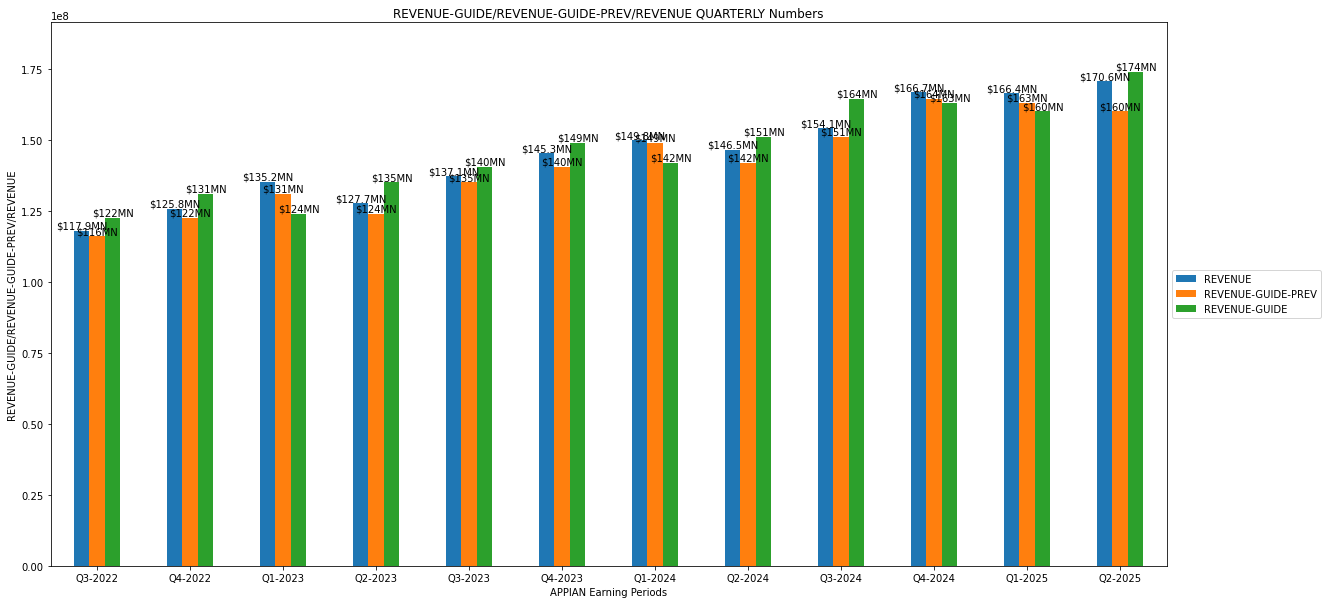

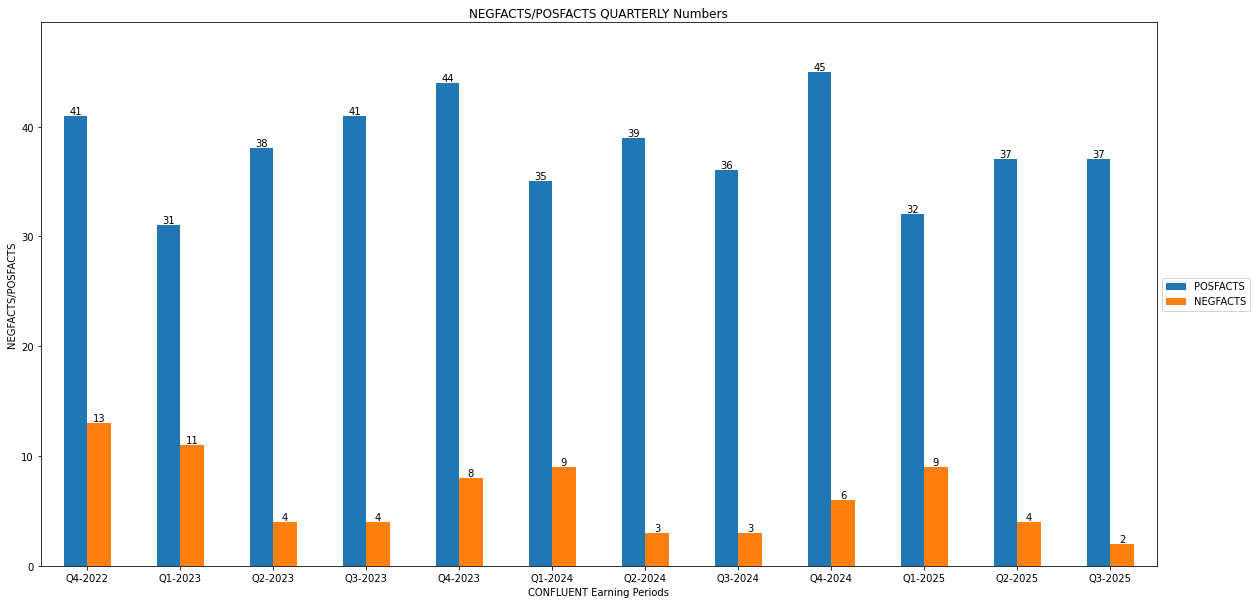

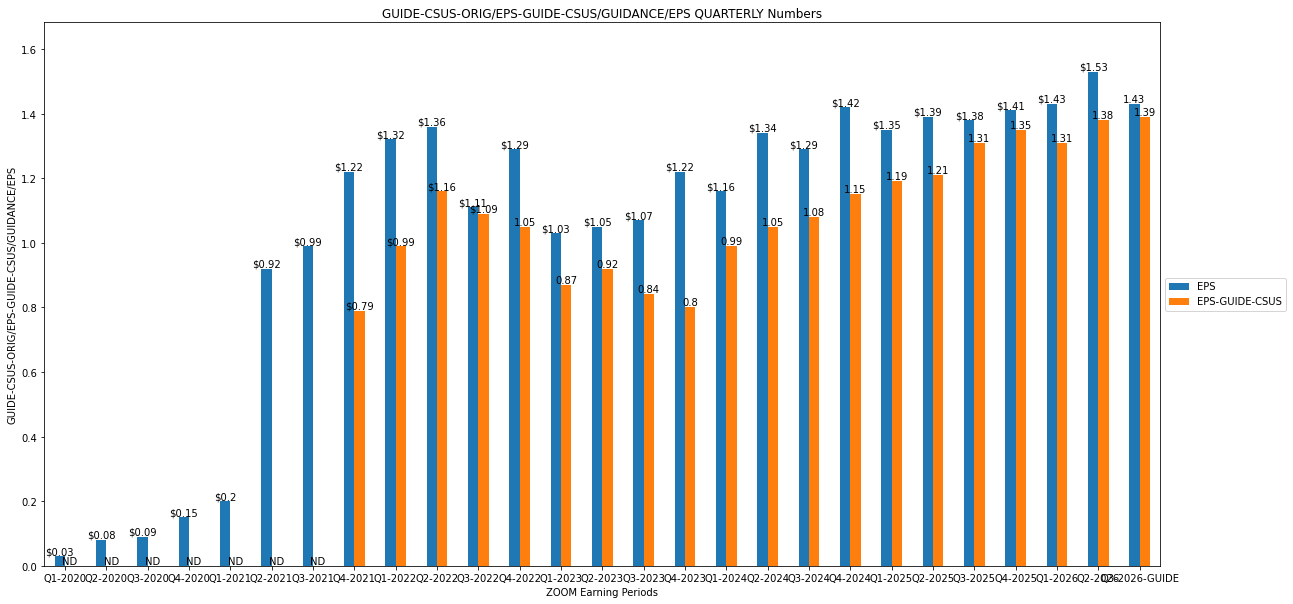

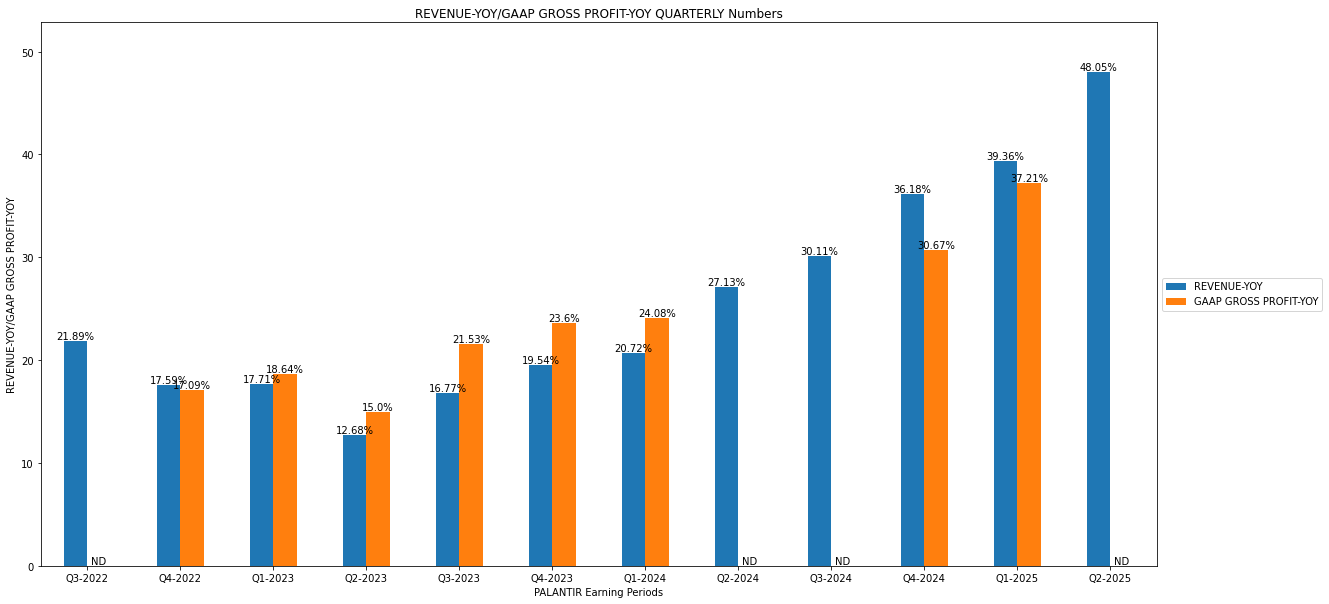

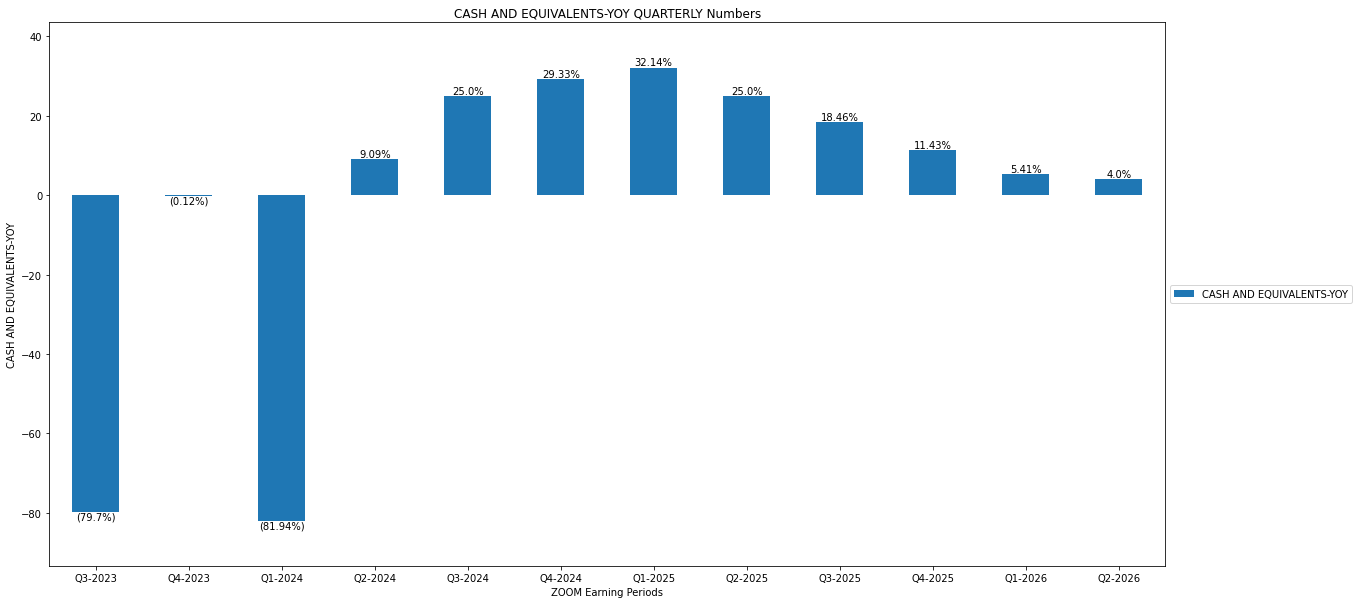

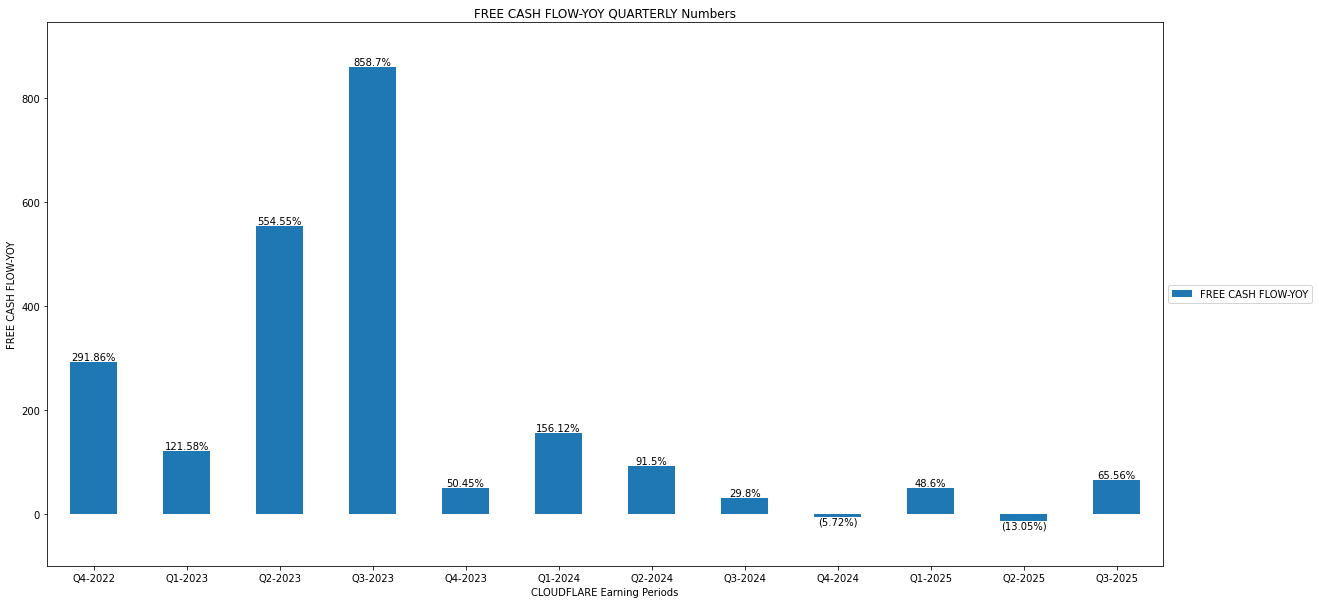

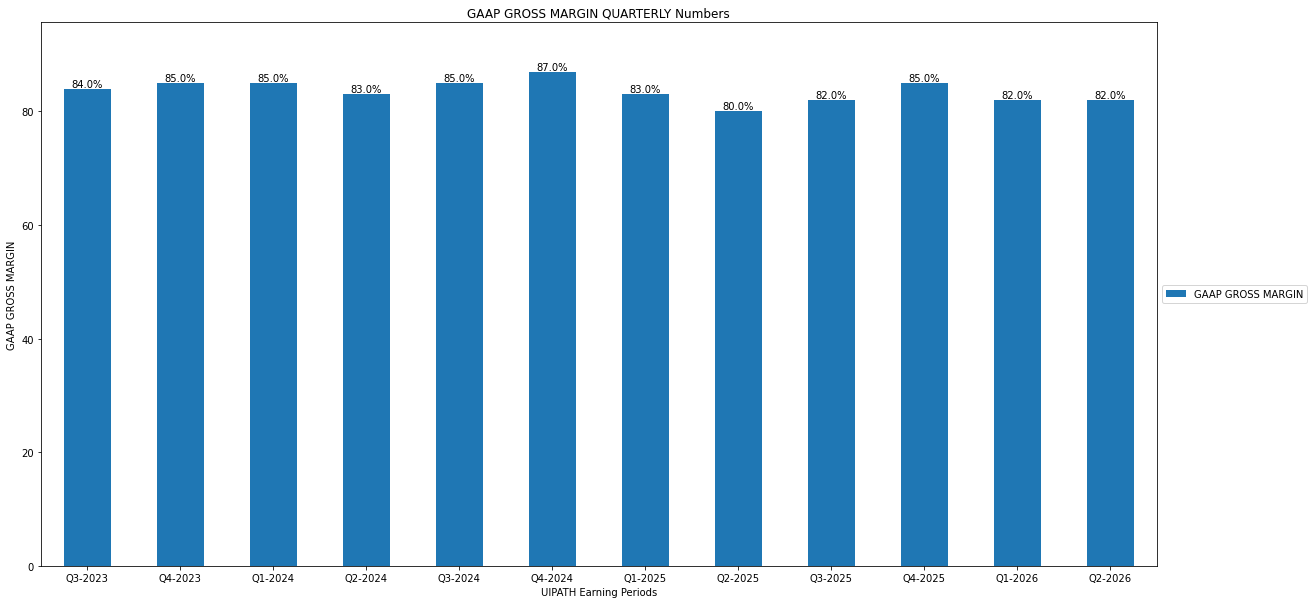

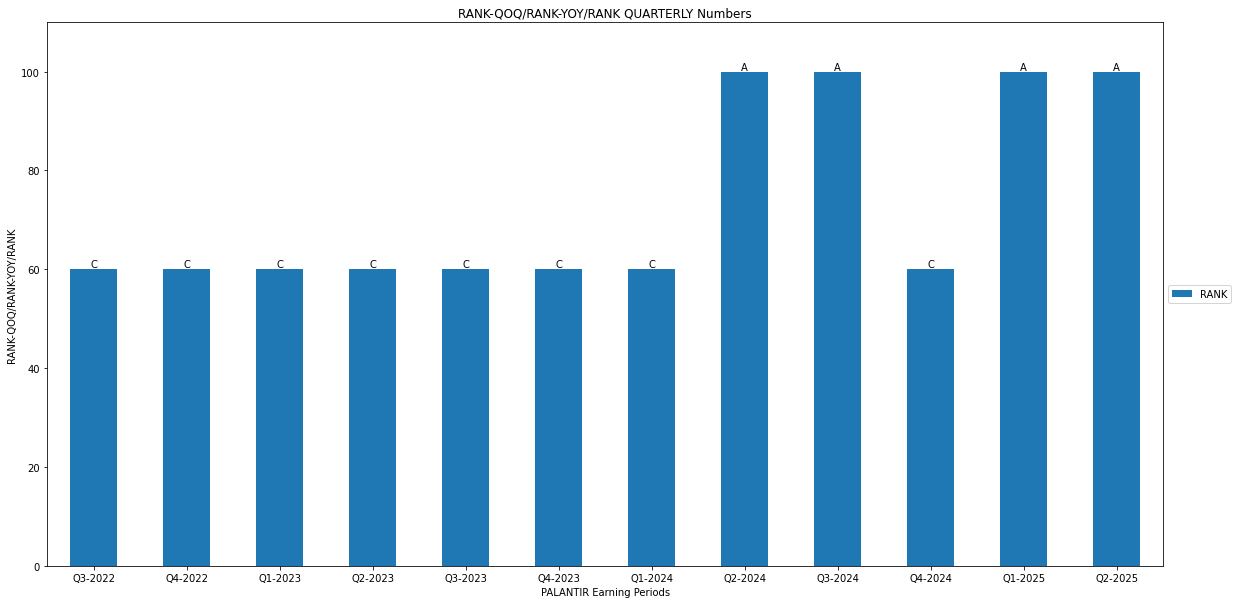

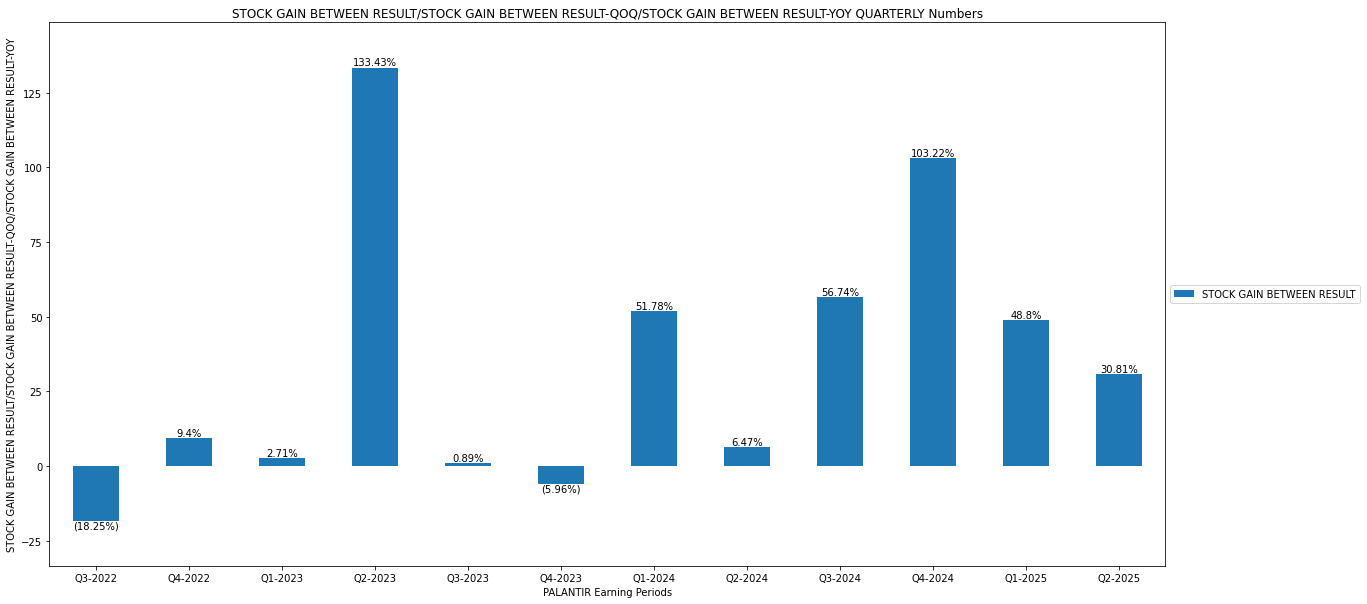

In [46]:
qcnt = 0
for q,intent,args,ans in zip(qa, qargs["INTENT"],qargs["ARGS"],qargs["ANS"]):
    #print(q)
    #print(intent) 
    #print(args) 
    #print(ans)
    #print()
    
    qcnt = qcnt + 1
    
    genData = dict()
    genData["INTENT"] = intent
    genData["ARGS"] = args
    genData["QUESTION"] = q
    genData["ANS"] = ans
    #print(genData)
    #print()
    
    new_args = buildArgsFromGenData(genData)
    #print(org_to_sym)
    if not new_args:
        print(">>>",q)
        print()
        print(naStr)
        if(qcnt >= 2):
            break
        continue
    
    gData = getTableData(new_args)
    #print(gData)
    if gData is None:
        print(">>>",q)
        print()
        print(naStr)
        if(qcnt >= 2):
            break
        continue

    print()
    print(">>>",q)
    #print()
    answer = getAns(genData, gData)
    if(answer):
        print(answer)
        print()
    
    if(qcnt >= 33):
        break